# Zoodle – klassificering av handritade djur

## Projektidé

Zoodle undersöker om ett convolutional neural network (CNN) kan lära sig att skilja mellan handritade djur. Handritade bilder är intressanta eftersom samma djur kan ritas på många olika sätt, samtidigt som flera djur har liknande silhuetter. Det gör klassificeringen till ett tydligt men utmanande problem.

Projektet bygger på [Quick, Draw!](https://github.com/googlecreativelab/quickdraw-dataset), ett dataset från Google, och omfattar 48 djurklasser. Ett komplett flöde har byggts för nedladdning, dataförberedelse, EDA, PCA, UMAP, träning av en klassisk PCA + KNN-baseline och en CNN samt slutlig utvärdering. Notebooken presenterar resultaten från de redan genomförda stegen utan att köra om dem.

## Så används notebooken **(viktigt)**

När notebooken körs läser den endast in projektets befintliga kod och redan sparade resultat. Den startar inte dataförberedelse, analys, träning eller utvärdering på nytt. För att skapa nya resultat eller träna en ny modell startas i stället projektets meny med `python pipeline.py`, där användaren väljer det aktuella steget.

Om notebooken redan har körts men projektets sparade resultat inte är tillgängliga bör den inte köras igen.

## Problemformulering

Varje bild är en gråskalebild med storleken $28 \times 28$ pixlar. Uppgiften är en övervakad multiklassklassificering där modellen ska tilldela bilden en av 48 möjliga djurklasser.

Projektet använder 20 000 bilder per klass, vilket ger totalt 960 000 bilder. Datamängden delas stratifierat i 70 procent träning, 15 procent validering och 15 procent test. Valideringsdata används under modellutvecklingen, medan testdata används för den slutliga utvärderingen.

In [1]:
import os
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

from settings import (
    ANIMAL_CLASSES,
    CNN_EVALUATION_OUTPUT_DIR,
    EDA_OUTPUT_DIR,
    KNN_EVALUATION_OUTPUT_DIR,
    PCA_OUTPUT_DIR,
    TRAINING_OUTPUT_DIR,
    UMAP_OUTPUT_DIR,
)

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

if not Path("settings").is_dir() or not Path("output").is_dir():
    raise RuntimeError(
        "Starta notebooken från projektroten så att settings och output kan hittas."
    )

CNN_CHECKPOINT_ID = "20260728_155542"
KNN_CHECKPOINT_ID = "20260728_111423"

training_dir = TRAINING_OUTPUT_DIR / CNN_CHECKPOINT_ID
evaluation_dir = CNN_EVALUATION_OUTPUT_DIR / CNN_CHECKPOINT_ID
knn_evaluation_dir = KNN_EVALUATION_OUTPUT_DIR / KNN_CHECKPOINT_ID


def require_files(paths, instruction):
    missing_paths = [path for path in paths if not path.exists()]
    if missing_paths:
        missing_text = "\n".join(f"- {path}" for path in missing_paths)
        raise FileNotFoundError(
            f"Följande resultatfiler saknas:\n{missing_text}\n\n{instruction}"
        )


def read_summary_metric(summary_text, label):
    prefix = f"{label}:"
    for line in summary_text.splitlines():
        if line.startswith(prefix):
            return float(line.split(":", maxsplit=1)[1].strip())
    raise ValueError(f"Måttet '{label}' saknas i sammanfattningen.")


print(f"CNN-checkpoint: {CNN_CHECKPOINT_ID}")
print(f"KNN-checkpoint: {KNN_CHECKPOINT_ID}")

CNN-checkpoint: 20260728_155542
KNN-checkpoint: 20260728_111423


## Dataförberedelse

Bilddata fungerar annorlunda än ett vanligt tabulärt dataset. Bilderna lagras som `uint8`, vilket innebär att varje pixel är ett heltal mellan 0 och 255. Därför kan bilderna inte innehålla vanliga saknade värden som `NaN`. I stället kontrolleras att alla klassfiler finns, att bilderna har rätt form och datatyp, att pixelvärdena ligger inom intervallet och att bilderna inte är helt tomma.

Det finns heller inga kategoriska indatavariabler som behöver `one-hot encoding`. Indatan består enbart av pixlar. Djurklassen är målvariabeln och kodas som heltal från 0 till 47 enligt den fasta ordningen i `ANIMAL_CLASSES`. Det passar TensorFlows `sparse_categorical_crossentropy`, som kan arbeta direkt med heltalsetiketter.

## Explorativ dataanalys

EDA - TRÄNINGSDATA
Antal bilder: 672000
Antal klasser: 48
Bildform: (28, 28, 1)
Datatyp: uint8
Minsta pixelvärde: 0
Största pixelvärde: 255
Tomma bilder: 0
Minsta antal bilder per klass: 14000
Största antal bilder per klass: 14000
Genomsnittligt antal pixlar med bläck: 230.71
Medianantal pixlar med bläck: 226.00


Antal klasser,Bilder per klass,Minsta,Största,Balanskvot
48,14 000,14 000,14 000,"1,00"


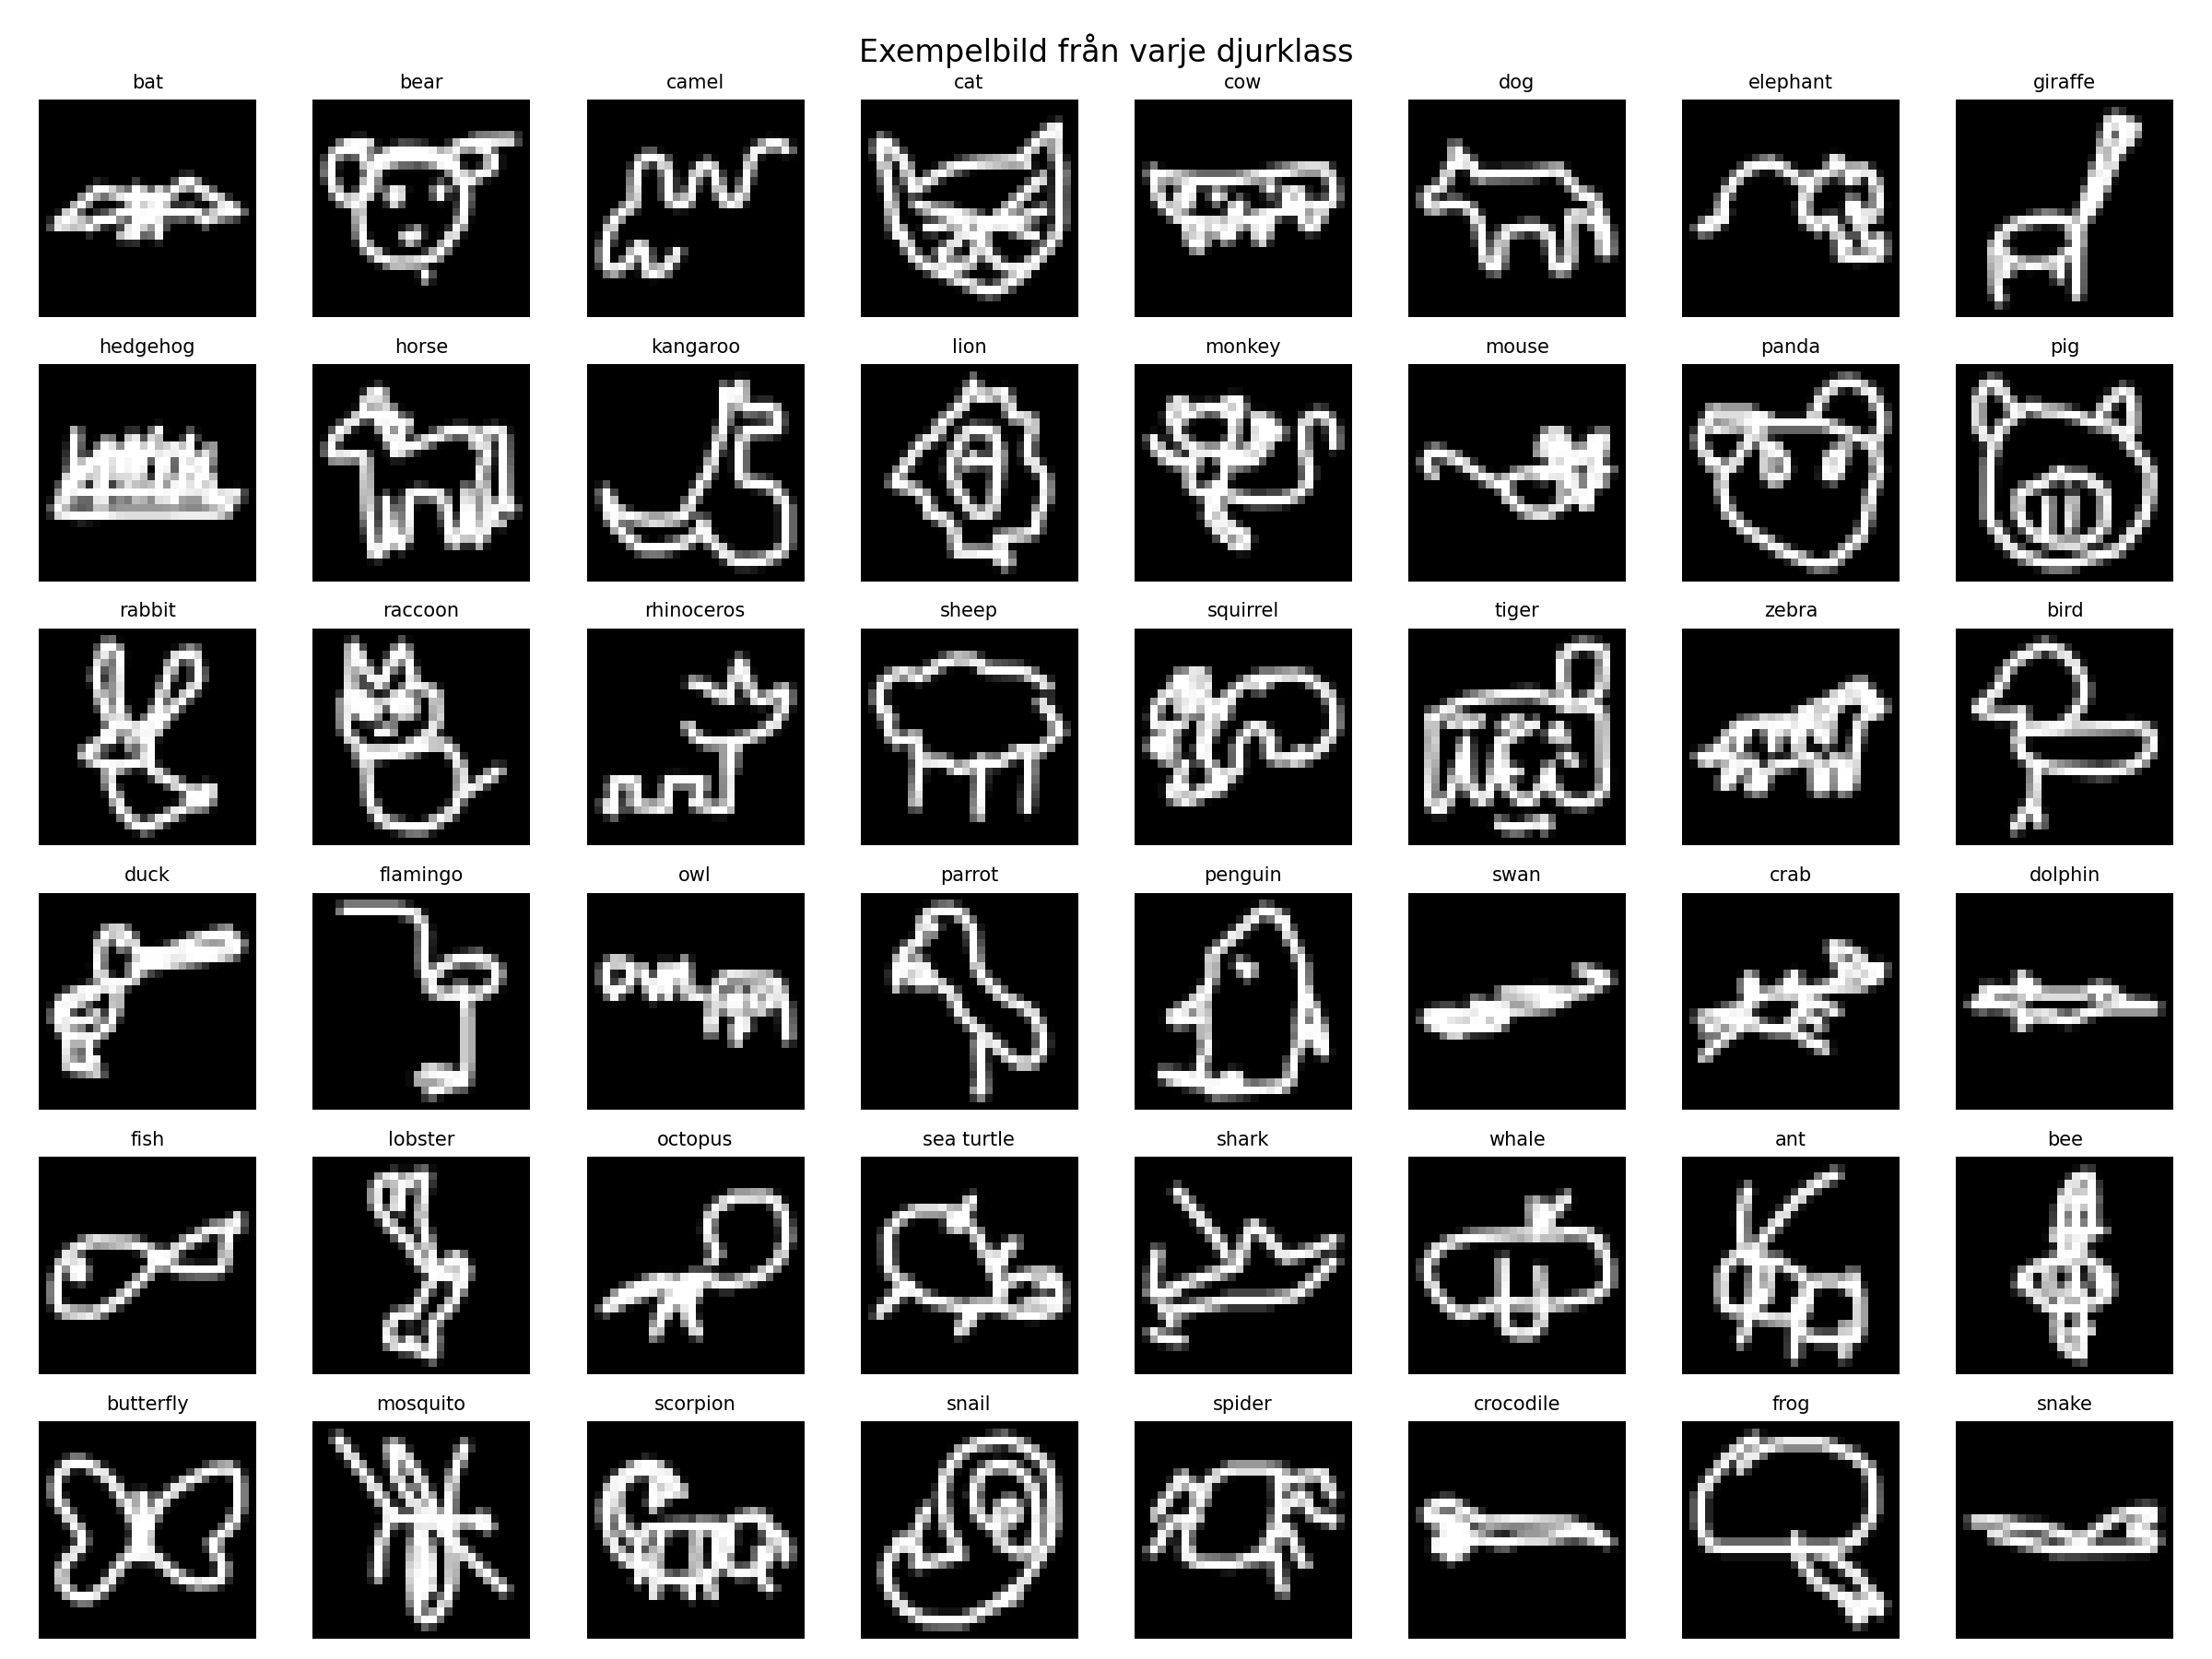

In [2]:
eda_paths = [
    EDA_OUTPUT_DIR / "summary.txt",
    EDA_OUTPUT_DIR / "class_statistics.csv",
    EDA_OUTPUT_DIR / "sample_images.png",
]
require_files(eda_paths, "Kör pipeline-steg 3 för att skapa EDA-resultaten.")

eda_summary = (EDA_OUTPUT_DIR / "summary.txt").read_text(encoding="utf-8")
class_statistics = pd.read_csv(EDA_OUTPUT_DIR / "class_statistics.csv")
class_counts = class_statistics["image_count"]
balance_table = pd.DataFrame(
    [
        {
            "number_of_classes": len(class_statistics),
            "images_per_class": int(class_counts.iloc[0]),
            "minimum": int(class_counts.min()),
            "maximum": int(class_counts.max()),
            "balance_ratio": class_counts.min() / class_counts.max(),
        }
    ]
)

print(eda_summary)
display(
    balance_table.rename(
        columns={
            "number_of_classes": "Antal klasser",
            "images_per_class": "Bilder per klass",
            "minimum": "Minsta",
            "maximum": "Största",
            "balance_ratio": "Balanskvot",
        }
    ).style.format(
        {
            "Bilder per klass": lambda value: f"{value:,}".replace(",", " "),
            "Minsta": lambda value: f"{value:,}".replace(",", " "),
            "Största": lambda value: f"{value:,}".replace(",", " "),
            "Balanskvot": lambda value: f"{value:.2f}".replace(".", ","),
        }
    ).hide(axis="index")
)
display(Image(filename=str(EDA_OUTPUT_DIR / "sample_images.png"), width=1000))

Djurklass,Antal bilder,Genomsnittligt antal bläckpixlar,Medianantal bläckpixlar
snake,14000,"146,09","137,00"
crocodile,14000,"161,97","151,00"
mouse,14000,"171,30","161,00"
dolphin,14000,"172,41","167,00"
shark,14000,"176,71","173,00"
monkey,14000,"269,44","268,00"
bee,14000,"270,65","271,00"
butterfly,14000,"274,36","275,00"
panda,14000,"297,86","298,00"
lion,14000,"310,66","316,00"


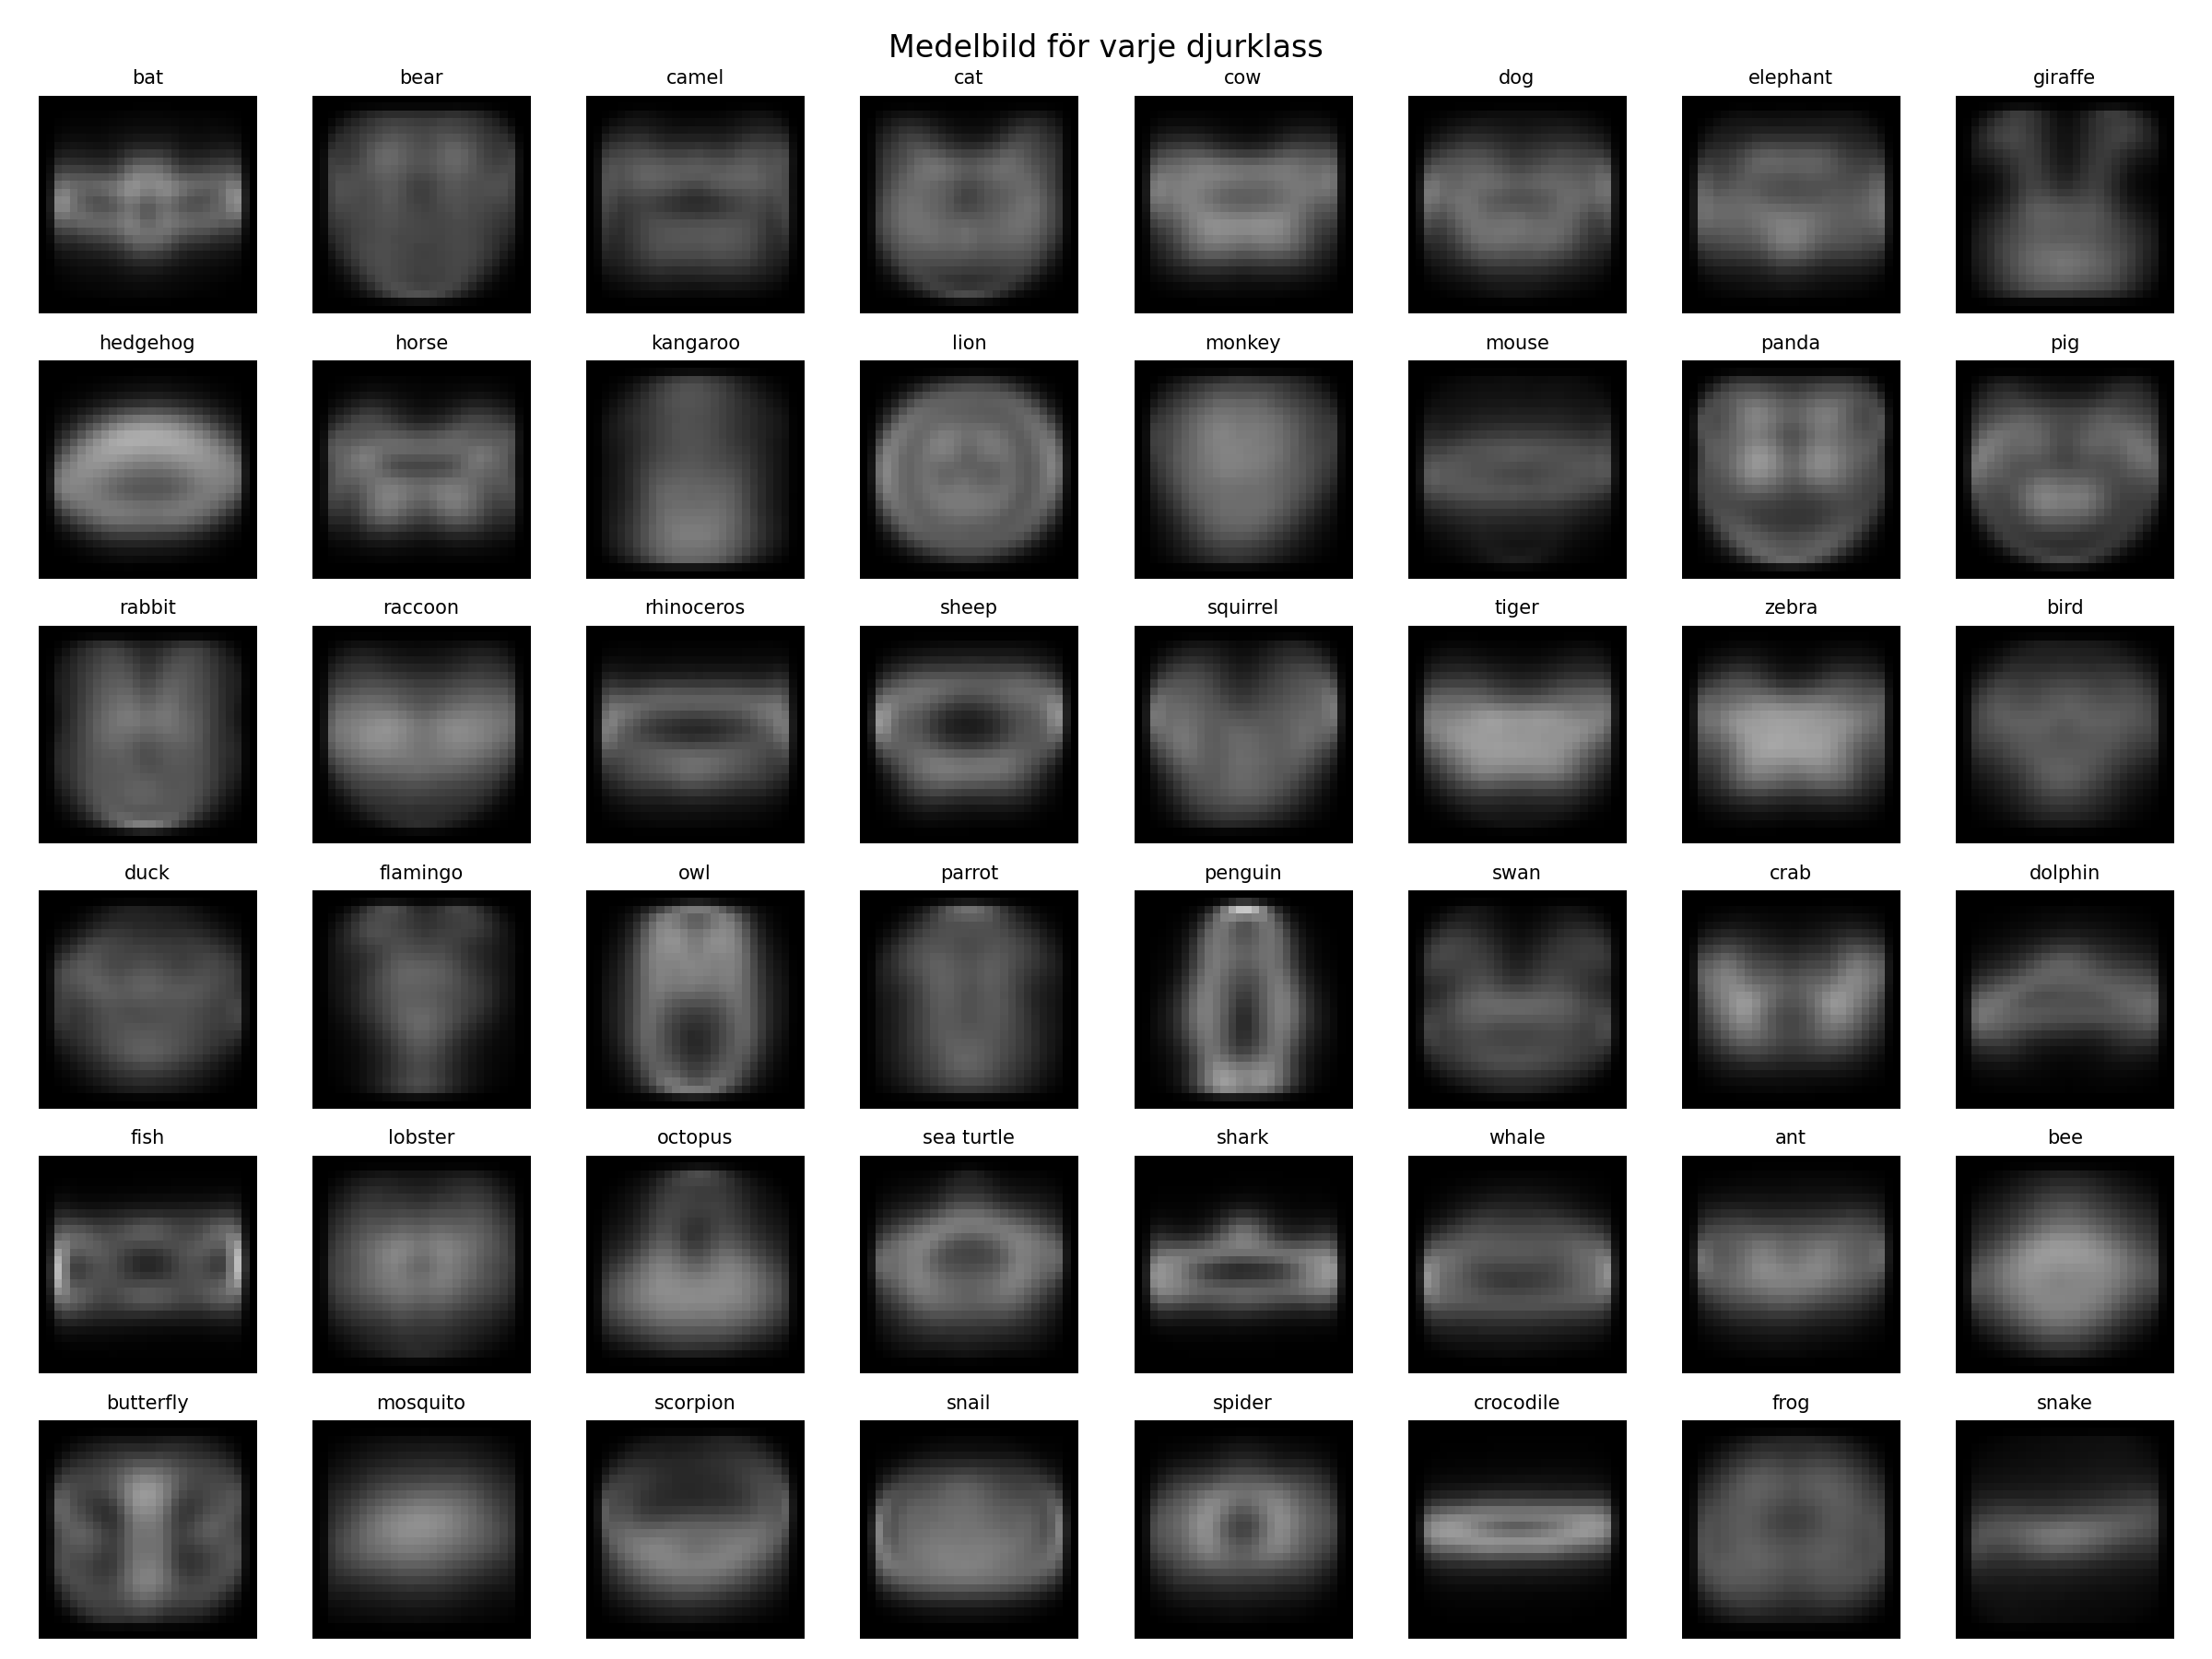

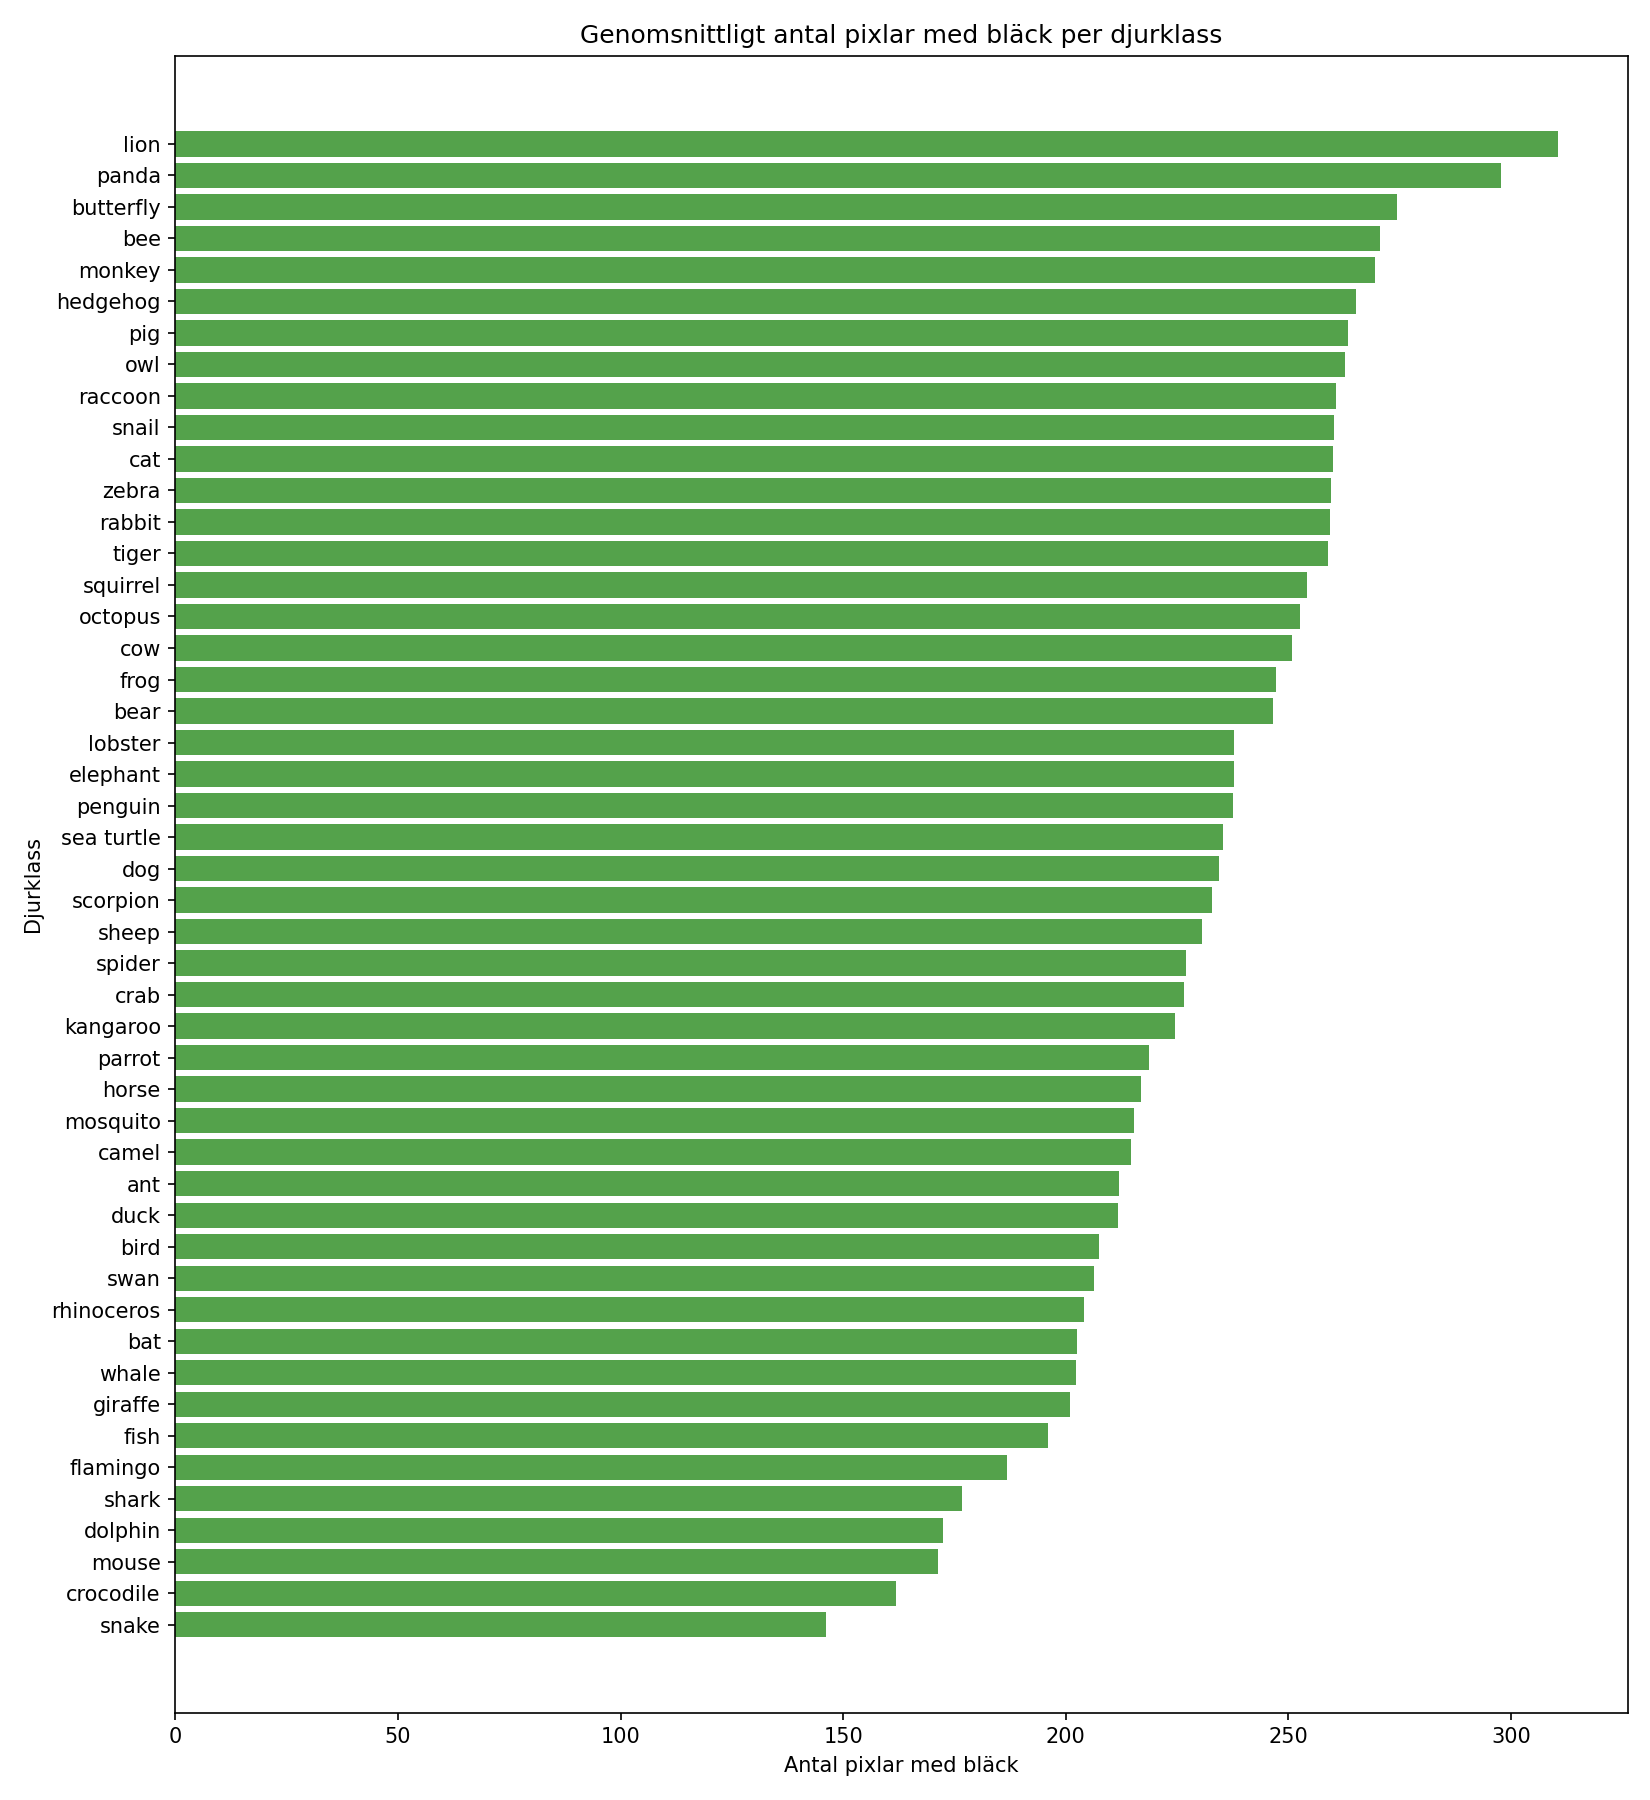

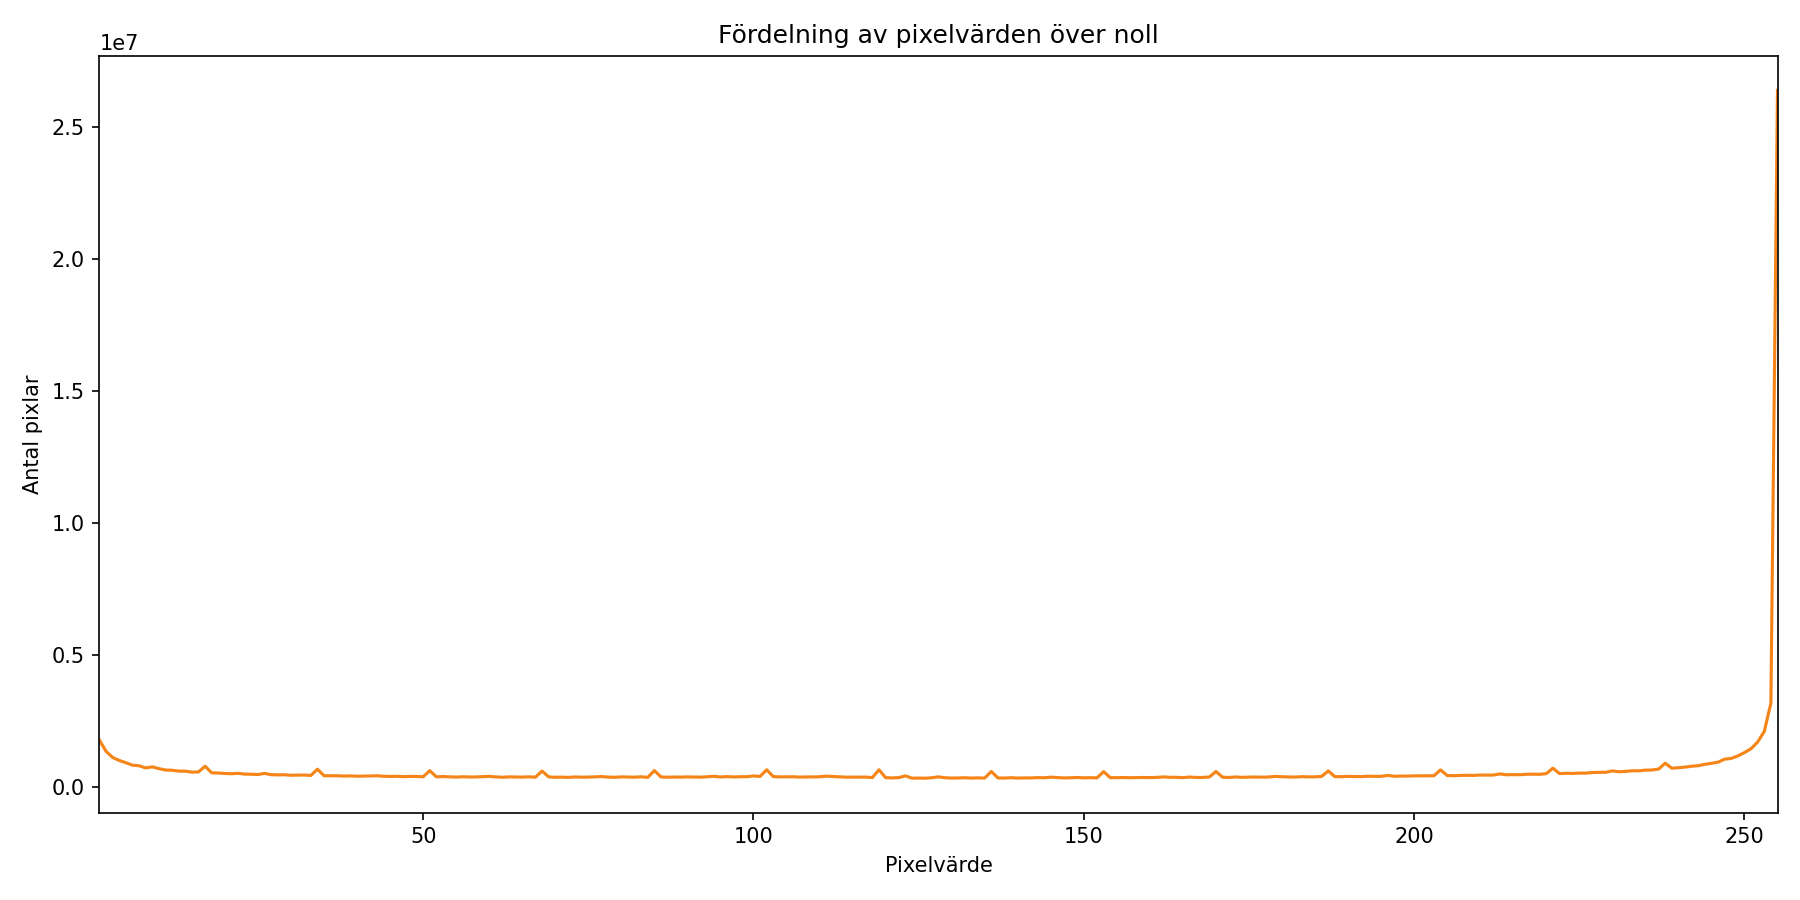

In [3]:
ink_extremes = pd.concat(
    [
        class_statistics.nsmallest(5, "average_ink_pixels"),
        class_statistics.nlargest(5, "average_ink_pixels"),
    ]
).drop_duplicates()

display(
    ink_extremes[["animal", "image_count", "average_ink_pixels", "median_ink_pixels"]]
    .sort_values("average_ink_pixels")
    .rename(
        columns={
            "animal": "Djurklass",
            "image_count": "Antal bilder",
            "average_ink_pixels": "Genomsnittligt antal bläckpixlar",
            "median_ink_pixels": "Medianantal bläckpixlar",
        }
    )
    .style.format(
        {
            "Genomsnittligt antal bläckpixlar": lambda value: f"{value:.2f}".replace(".", ","),
            "Medianantal bläckpixlar": lambda value: f"{value:.2f}".replace(".", ","),
        }
    ).hide(axis="index")
)

for filename in [
    "average_images.png",
    "average_ink_per_class.png",
    "pixel_intensity_distribution.png",
]:
    image_path = EDA_OUTPUT_DIR / filename
    require_files([image_path], "Kör pipeline-steg 3 för att skapa EDA-resultaten.")
    display(Image(filename=str(image_path), width=1000))

### Tolkning av EDA

Träningsdatasetet är helt balanserat med 14 000 bilder per klass. Det gör att ingen klass dominerar träningen och att macro- och weighted-måtten senare blir direkt jämförbara. Inga tomma bilder finns kvar efter dataförberedelsen.

En bild innehåller i genomsnitt 230,71 pixlar med bläck, men skillnaden mellan klasserna är tydlig. `snake` har lägst genomsnitt med ungefär 146 pixlar medan `lion` har högst med ungefär 311. Det tyder på att vissa djur ofta ritas som enkla konturer medan andra innehåller fler detaljer. Exempelbilderna visar samtidigt stor variation inom varje klass, vilket är en viktig del av klassificeringsproblemet.

## PCA

PCA används för att undersöka hur mycket av bildinformationen som kan sammanfattas med färre dimensioner. Analysen använder ett balanserat urval från träningsdata och etiketterna används endast efteråt för visualisering.

PCA - TRÄNINGSDATA
Antal bilder: 48000
Bilder per klass: 1000
Antal ursprungliga pixlar: 784
Antal PCA-komponenter: 280
Bevarad varians: 0.9501

De två första komponenterna förklarar 10,98% av variationen,


Förklarad varians,Antal komponenter
50%,34
80%,123
90%,201
95%,280


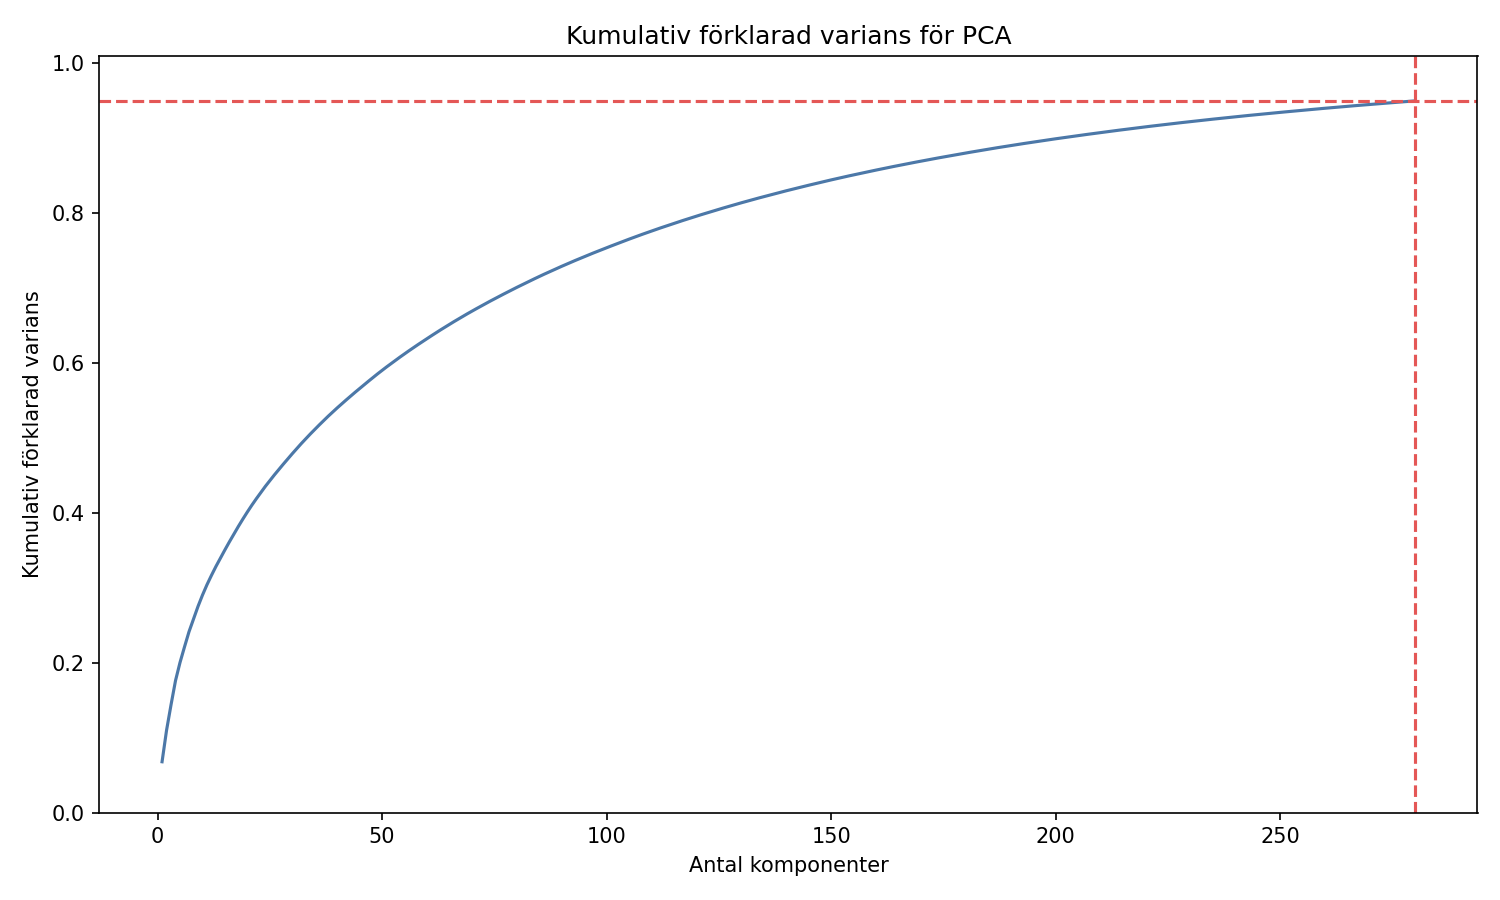

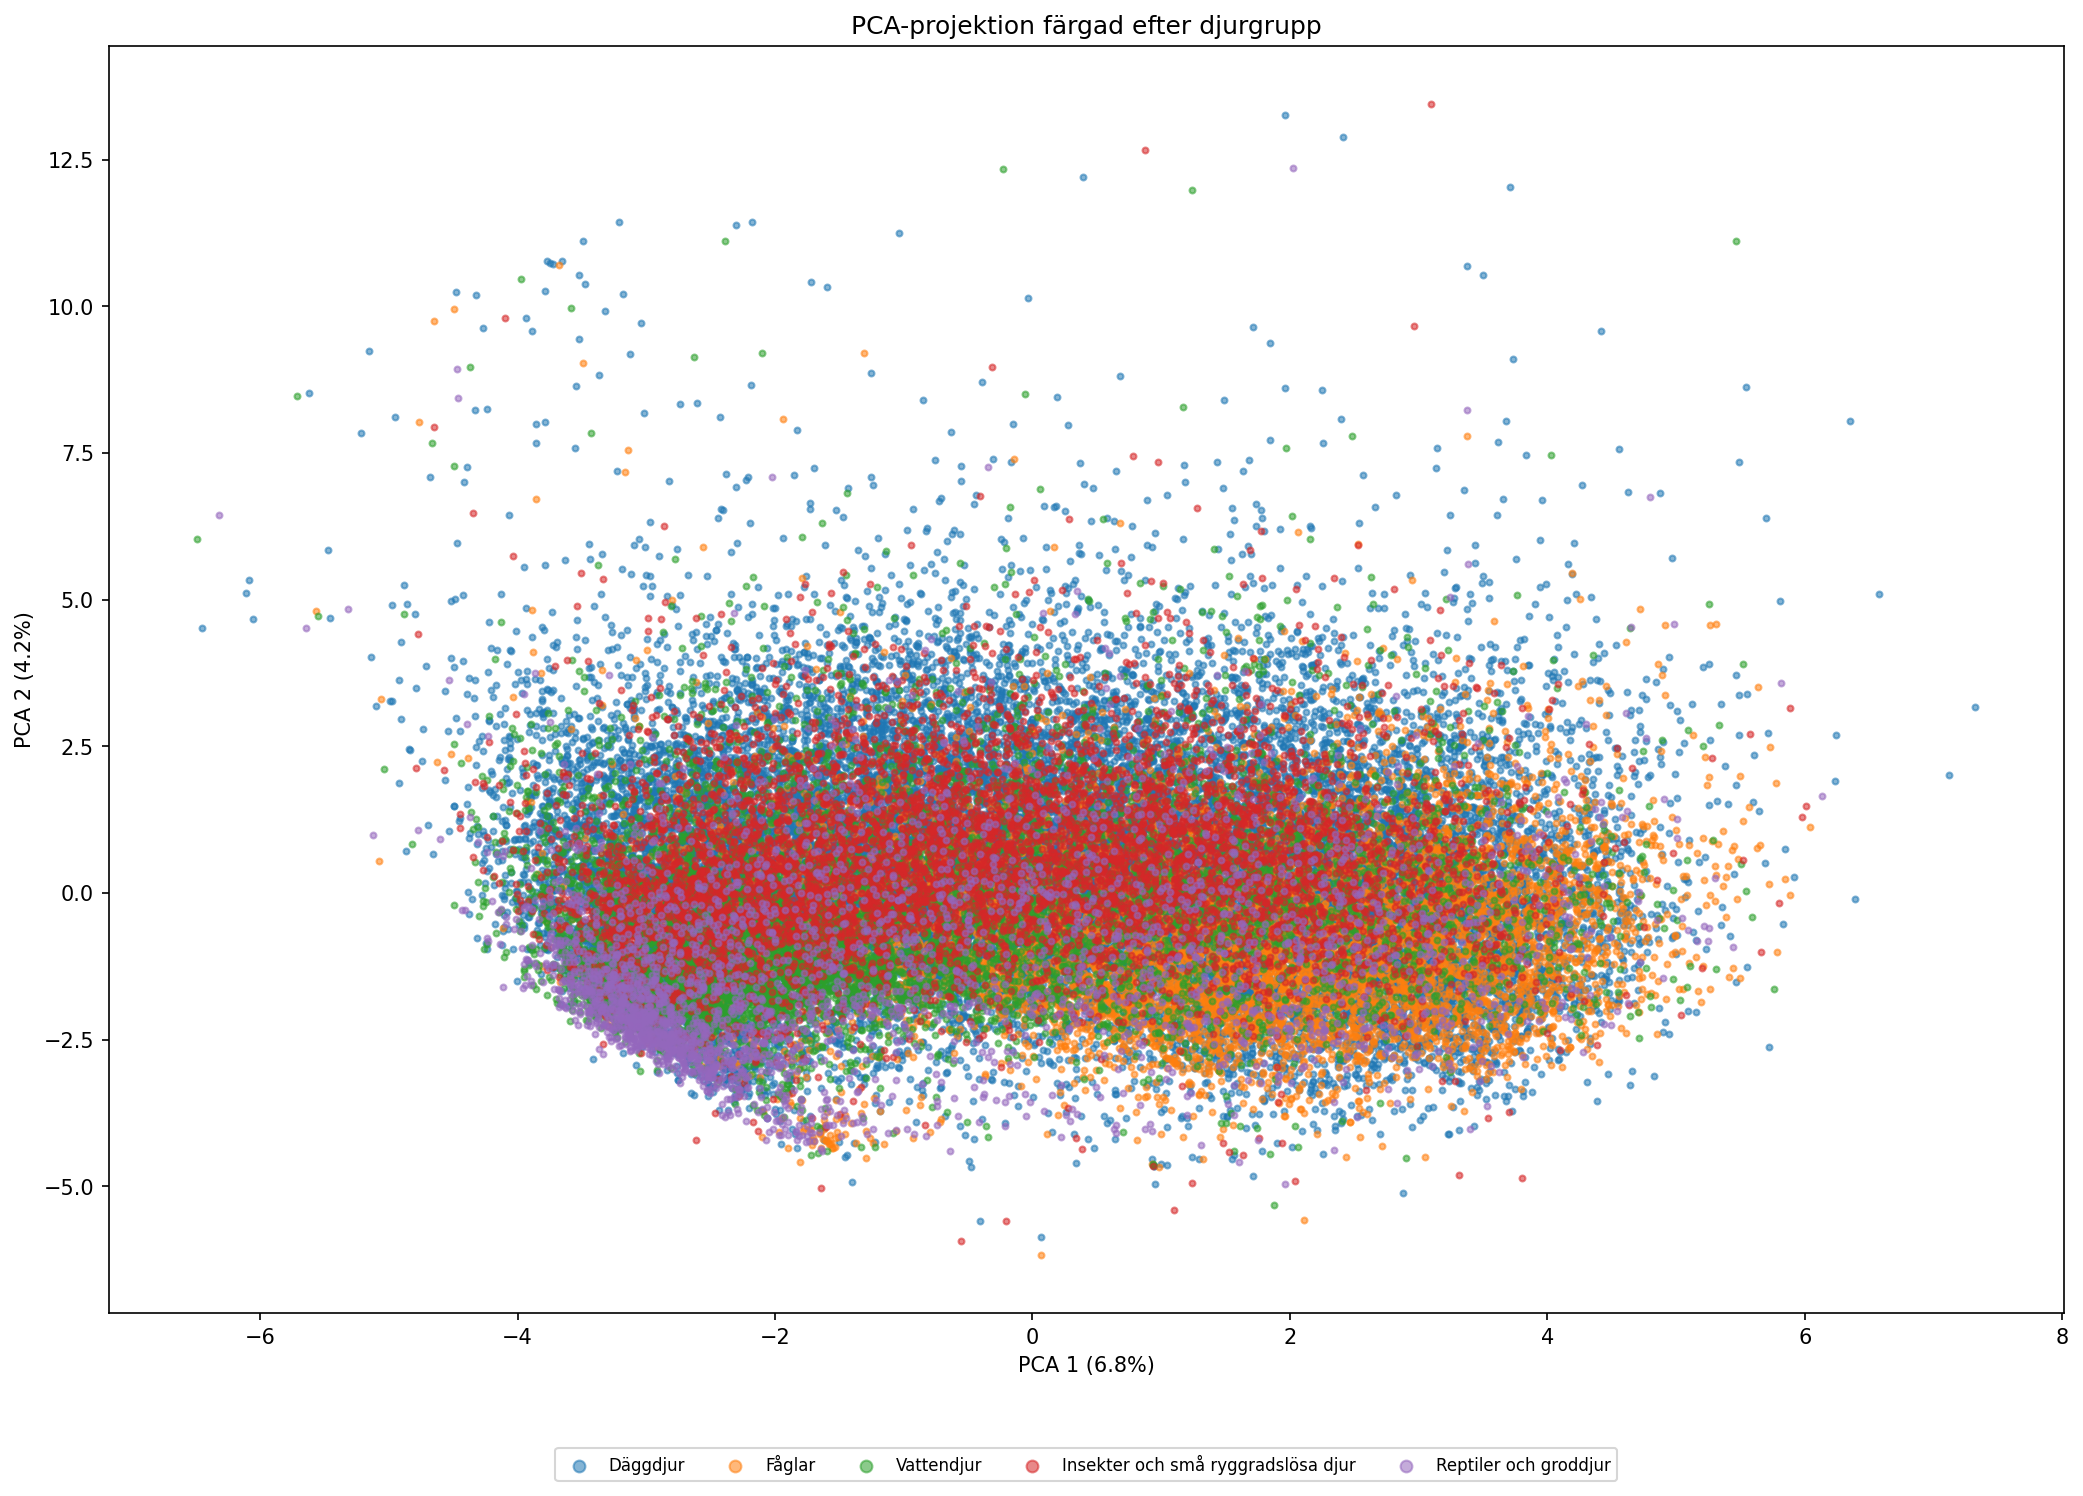

In [4]:
pca_paths = [
    PCA_OUTPUT_DIR / "summary.txt",
    PCA_OUTPUT_DIR / "explained_variance.csv",
    PCA_OUTPUT_DIR / "explained_variance.png",
    PCA_OUTPUT_DIR / "projection_by_group.png",
]
require_files(pca_paths, "Kör pipeline-steg 4 för att skapa PCA-resultaten.")

pca_summary = (PCA_OUTPUT_DIR / "summary.txt").read_text(encoding="utf-8")
explained_variance = pd.read_csv(PCA_OUTPUT_DIR / "explained_variance.csv")
first_two_variance = explained_variance.head(2)["explained_variance_ratio"].sum()

variance_levels = []
for target in [0.50, 0.80, 0.90, 0.95]:
    component_count = int(
        (explained_variance["cumulative_explained_variance"] < target).sum() + 1
    )
    variance_levels.append(
        {"explained_variance": f"{target:.0%}", "components": component_count}
    )

print(pca_summary)
print(
    f"\nDe två första komponenterna förklarar {first_two_variance:.2%} av variationen."
    .replace(".", ",")
)
display(
    pd.DataFrame(variance_levels)
    .rename(
        columns={
            "explained_variance": "Förklarad varians",
            "components": "Antal komponenter",
        }
    )
    .style.hide(axis="index")
)
display(Image(filename=str(PCA_OUTPUT_DIR / "explained_variance.png"), width=900))
display(Image(filename=str(PCA_OUTPUT_DIR / "projection_by_group.png"), width=1100))

### Tolkning av PCA

Det krävs 280 komponenter för att bevara 95,01 procent av variationen. De två komponenter som visas i projektionen förklarar tillsammans bara cirka 10,98 procent. Den kraftiga överlappningen i två dimensioner är därför väntad och betyder inte att all information saknas.

Resultatet tyder på att djurgrupperna inte kan separeras linjärt utifrån de råa pixlarna. Samma djur kan ritas på flera sätt och olika djur kan ha liknande konturer. Detta motiverar att en klassisk PCA + KNN-baseline jämförs med en icke-linjär modell som en CNN. Den explorativa PCA-analysen används för att förstå data; KNN-flödet tränar en egen PCA enbart på sitt träningsunderlag och CNN-modellen använder originalbilderna.

## UMAP

UMAP används för att skapa en icke-linjär projektion där lokal struktur kan bli tydligare än i PCA. UMAP arbetar på PCA-representationen och använder inte klassernas etiketter när projektionen skapas.

UMAP - TRÄNINGSDATA
Antal bilder: 24000
Bilder per klass: 500
Antal PCA-komponenter som indata: 280
n_neighbors: 15
min_dist: 0.1
Mått: euclidean


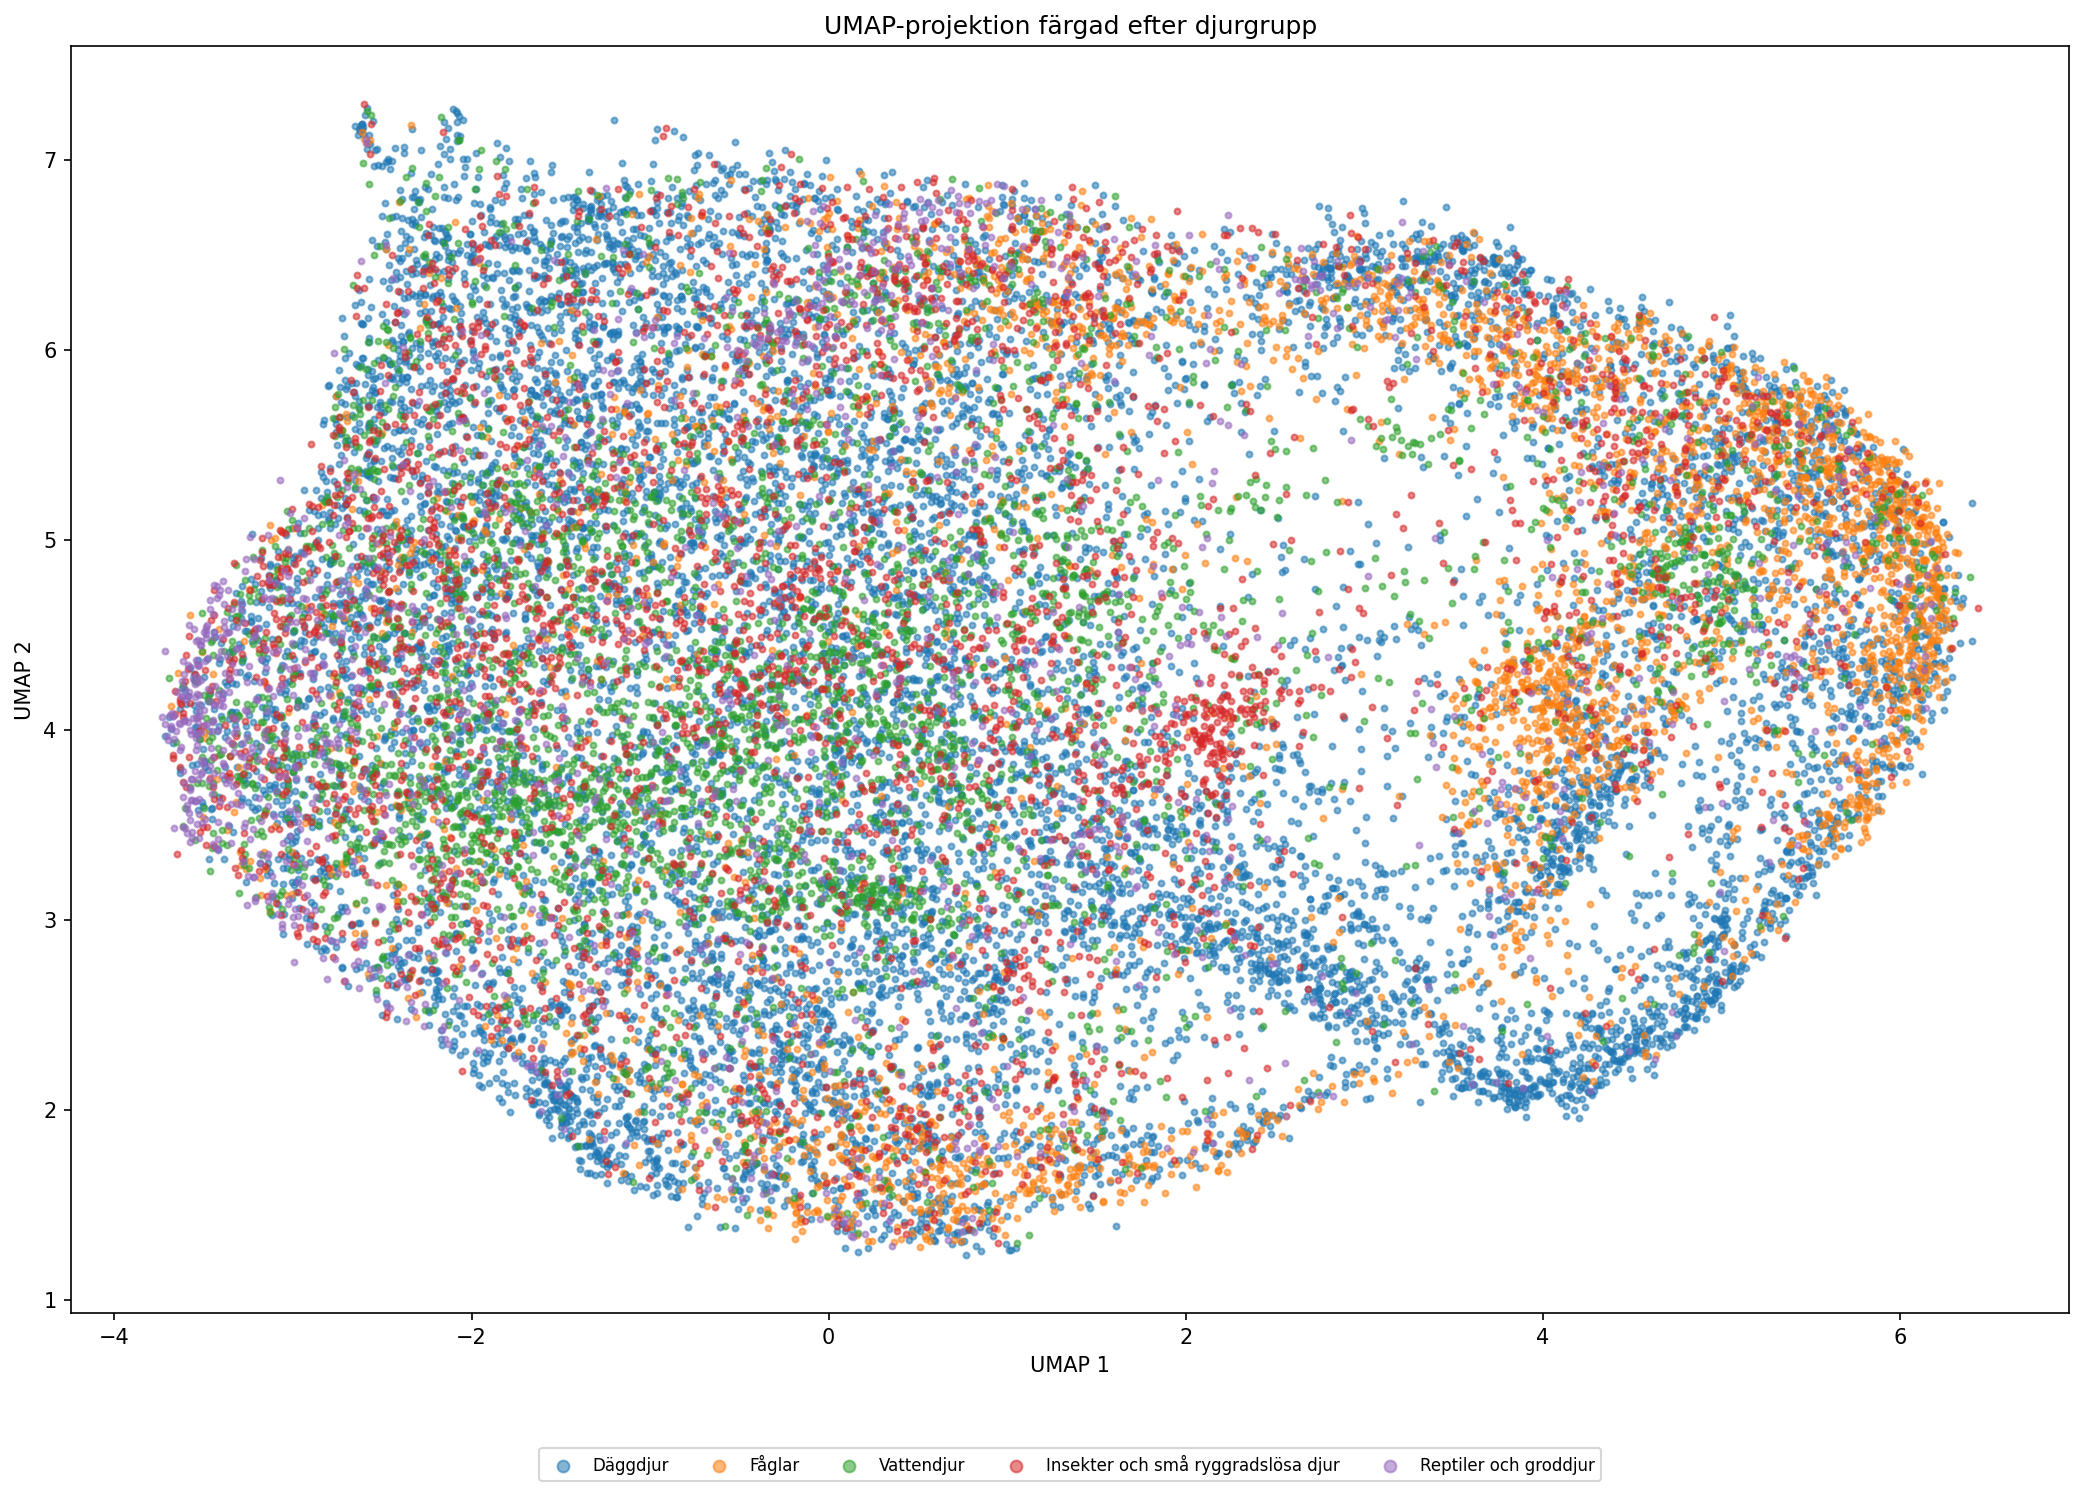

In [5]:
umap_paths = [
    UMAP_OUTPUT_DIR / "summary.txt",
    UMAP_OUTPUT_DIR / "projection_by_group.png",
]
require_files(umap_paths, "Kör pipeline-steg 4 för att skapa UMAP-resultaten.")

umap_summary = (UMAP_OUTPUT_DIR / "summary.txt").read_text(encoding="utf-8")
print(umap_summary)
display(Image(filename=str(UMAP_OUTPUT_DIR / "projection_by_group.png"), width=1100))

### Tolkning av UMAP

UMAP visar mer lokal struktur än PCA, men djurgruppernas färger är fortfarande kraftigt blandade. Fåglar syns oftare i den högra delen och reptiler och groddjur oftare i den vänstra, men det finns ingen tydlig gräns mellan grupperna. UMAP-axlarna har ingen egen semantisk betydelse, så det är närheten mellan punkterna som ska tolkas.

En hypotes är att bilderna grupperas mer efter streckgeometri, orientering och silhuett än efter djurens taxonomiska grupp. Den hypotesen kan senare jämföras med modellens vanligaste felklassificeringar.

## Klassisk baseline: PCA + KNN

PCA + KNN används som en klassisk baseline för att ge CNN-resultatet ett relevant jämförelsevärde. Modellen tränades på samtliga 672 000 träningsbilder och validerades på 144 000 bilder. PCA-transformeringen som anpassades separat i KNN-flödet bevarade 95,03 procent av variationen med 282 komponenter. KNN använde fem avståndsviktade grannar, euklidiskt avstånd och sökalgoritmen `brute`.

På valideringsdata nådde modellen 48,99 procent accuracy och 47,89 procent macro F1. Att KNN-modellens PCA använder 282 komponenter medan den explorativa analysen använder 280 är inte en motsägelse: analyserna anpassas på olika stora dataunderlag. Den explorativa PCA:n bygger på ett balanserat urval, medan KNN:s PCA anpassas på hela träningsmängden.

## CNN-modellen och träningen

### Modellutveckling

CNN-modellen utvecklades genom fyra fullständiga träningskörningar. Körningarna gjordes i ordningen nedan och varje ny körning byggde vidare på resultatet från den föregående. Körning 3 och 4 använde samma arkitektur, men körning 4 var en ny träning från start med ett annat körsätt i TensorFlow.

| Körning | Förändring och körläge | Bästa `val_loss` | `val_accuracy` | Test accuracy | Test macro F1 |
|---|---|---:|---:|---:|---:|
| 1 | Första CNN-modellen: tre `Conv2D`-lager med 32, 64 och 128 filter samt `MaxPooling2D` efter varje lager. `graph mode`. | 1,6208 | 57,38 % | 57,03 % | 56,55 % |
| 2 | Ett fjärde `Conv2D`-lager med 256 filter och ytterligare `MaxPooling2D` lades till. `graph mode`. | 1,4455 | 62,42 % | 62,23 % | 62,13 % |
| 3 | Det sista `MaxPooling2D`-lagret togs bort. `GlobalMaxPooling2D` arbetar i stället direkt på representationen med storleken $3 \times 3$. `graph mode`. | 1,4149 | 62,90 % | 62,72 % | 62,68 % |
| 4 – slutmodell | Ingen arkitekturförändring. Arkitekturen från körning 3 tränades helt på nytt i `eager mode` under träning, validering och inference. | **1,1538** | **68,16 %** | **68,12 %** | **67,98 %** |

Körning 1 fungerade som den första baselinen. Körning 2 visade att ett djupare nätverk kunde förbättra resultatet, och körning 3 visade en mindre ytterligare förbättring när det sista `MaxPooling2D`-lagret togs bort. Körning 3 gav därmed det bästa valideringsresultatet bland körningarna i `graph mode` och avgjorde vilken arkitektur som skulle behållas.

Efter körning 3 upptäcktes att samma checkpoint kunde ge olika prediktioner när den kördes med TensorFlow Metal i `graph mode` och vid inference i `eager mode` på CPU. Därför tränades samma arkitektur helt på nytt i `eager mode` i körning 4. Körning 4 gav det bästa valideringsresultatet av samtliga körningar, kunde återskapas med inference i `eager mode` på CPU och är därför projektets slutliga CNN-modell. Körning 3 är alltså arkitekturförlagan, medan körning 4 är den slutliga tränade modellen. Den sparade checkpointen är `20260728_155542`. Arkitekturbesluten gjordes utifrån valideringsresultaten; testmåtten i tabellen redovisas som dokumenterad utvecklingshistorik.

### Slutlig arkitektur och träningsupplägg

Den sparade modellen från körning 4 använder fyra `Conv2D`-lager med 32, 64, 128 och 256 filter. De tre första följs av `MaxPooling2D`. Efter lagret med 256 filter används `GlobalMaxPooling2D` direkt, följt av ett `Dense`-lager med 128 neuroner, dropout och ett softmax-lager med 48 utgångar. När det sista `MaxPooling2D`-lagret togs bort kunde `GlobalMaxPooling2D` använda den kvarvarande representationen på $3 \times 3$ positioner i stället för att först komprimera den ytterligare.

Bilderna normaliseras i modellen. Under träningen används mild data augmentation med rotation, translation och zoom för att efterlikna variationen i handritade bilder. Träning, validering och inference körs i `eager mode` för att ge samma beräkningssätt på Metal och CPU.

`EarlyStopping` skyddar mot onödigt lång träning, `ModelCheckpoint` sparar modellen med lägst `val_loss` och `ReduceLROnPlateau` sänker learning rate när `val_loss` slutar förbättras.

MODELLTRÄNING - ZOODLE
Körnings-ID: 20260728_155542
Dataaugmentering: Ja
Rotation vid augmentering: 0.08
Förflyttning vid augmentering: 0.1
Zoom vid augmentering: 0.1
Dropout: 0.3
Träningsbilder: 672000
Valideringsbilder: 144000
Antal klasser: 48
Batchstorlek: 128
Eager mode: Ja
Maximalt antal epoker: 45
Genomförda epoker: 39
Early stopping: Ja
Tålamod för early stopping: 5
ReduceLROnPlateau: Ja
Tålamod för ReduceLROnPlateau: 2
Faktor för ReduceLROnPlateau: 0.5
Minsta learning rate: 1e-06
Initial learning rate: 0.0001
Learning rate under sista epoken: 0.00000312
Learning rate under bästa epoken: 0.00001250
Bästa epok: 34
Bästa valideringsförlust: 1.1538
Valideringsträffsäkerhet vid bästa epok: 0.6816
Sparad modell: artifacts/training/20260728_155542/best_model.keras


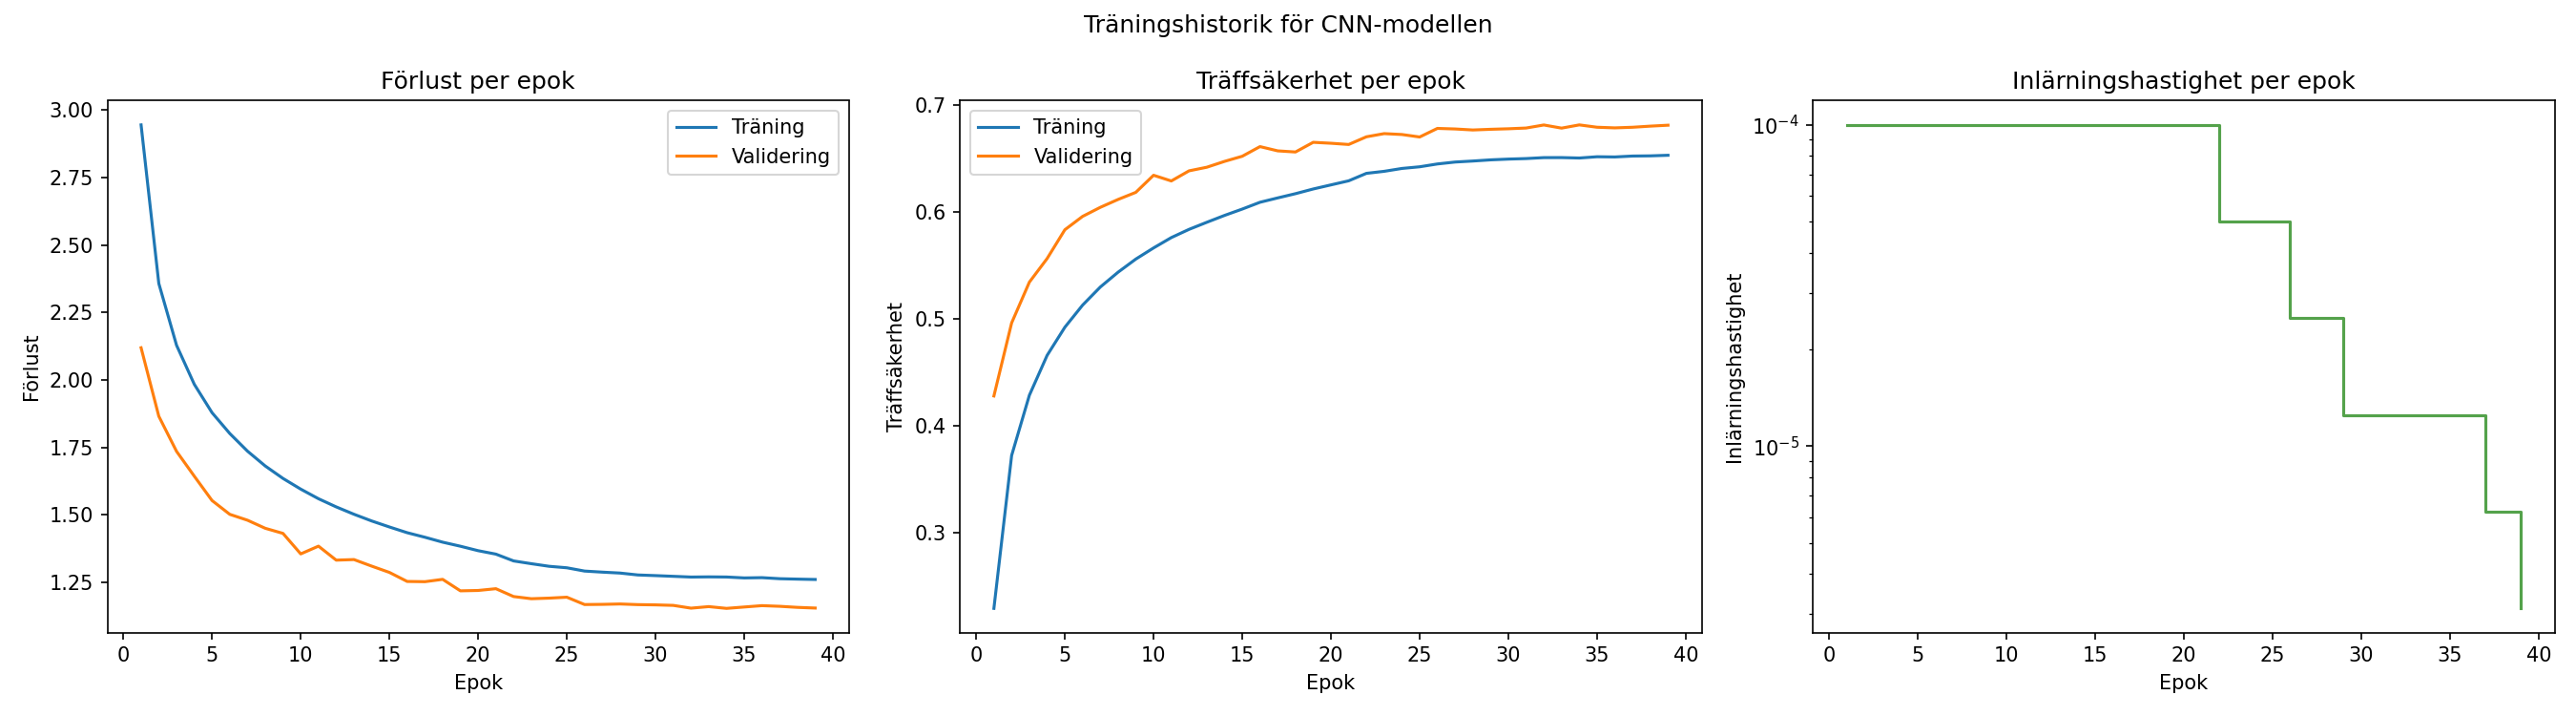

In [6]:
training_paths = [
    training_dir / "summary.txt",
    training_dir / "training_history.png",
]
require_files(training_paths, "Kör pipeline-steg 6 för att skapa träningsresultaten.")

training_summary = (training_dir / "summary.txt").read_text(encoding="utf-8")
training_overview = training_summary.split("MODELLARKITEKTUR")[0].strip()

print(training_overview)
display(Image(filename=str(training_dir / "training_history.png"), width=1200))

### Tolkning av träningen

Den bästa modellen hittades vid epok 34 med `val_loss` 1,1538 och `val_accuracy` 68,16 procent. Träningen pågick i 39 av högst 45 epoker innan `EarlyStopping` avbröt körningen. Learning rate sänktes stegvis från $10^{-4}$ till $3,125 \times 10^{-6}$; under den bästa epoken var den $1,25 \times 10^{-5}$.

Validation accuracy ligger högre än training accuracy. Det är rimligt eftersom data augmentation och dropout gör träningspassen svårare, medan de är avstängda när valideringsdata bedöms.

Den sparade checkpointen verifierades dessutom genom inference i `eager mode` på CPU. På hela valideringsmängden blev accuracy 68,1583 procent och loss 1,153491. På testmängden överensstämde samtliga 144 000 predikterade etiketter med den sparade utvärderingen; den största skillnaden mellan motsvarande confidence scores var 0,000004. Det visar att resultatet kan återskapas utan Metal.

## Slutlig utvärdering på testdata

Efter att modellen och dess inställningar har valts ut används den separata testmängden för slutlig utvärdering. En classification report skapas nedan från de redan sparade testprediktionerna.

In [7]:
predictions_path = evaluation_dir / "predictions.csv"
require_files(
    [predictions_path],
    "Kör pipeline-steg 7 och välj den aktuella checkpointen för att skapa testresultaten.",
)

predictions = pd.read_csv(predictions_path)
required_columns = {
    "true_label",
    "true_animal",
    "predicted_label",
    "predicted_animal",
    "confidence",
    "correct",
}
missing_columns = required_columns.difference(predictions.columns)
if missing_columns:
    raise ValueError(f"predictions.csv saknar kolumnerna: {sorted(missing_columns)}")

if len(predictions) != 144000:
    raise ValueError(
        f"Testresultatet innehåller {len(predictions)} rader i stället för 144000."
    )

from training import create_classification_report

test_report = create_classification_report(
    predictions["true_label"],
    predictions["predicted_label"],
    class_names=ANIMAL_CLASSES,
)
print(test_report)

Classification report

              precision    recall  f1-score   support

         bat       0.70      0.70      0.70      3000
        bear       0.53      0.28      0.37      3000
       camel       0.90      0.81      0.85      3000
         cat       0.65      0.64      0.65      3000
         cow       0.51      0.63      0.56      3000
         dog       0.47      0.35      0.40      3000
    elephant       0.59      0.72      0.65      3000
     giraffe       0.87      0.86      0.86      3000
    hedgehog       0.79      0.74      0.77      3000
       horse       0.54      0.77      0.63      3000
    kangaroo       0.73      0.79      0.76      3000
        lion       0.78      0.79      0.78      3000
      monkey       0.56      0.62      0.59      3000
       mouse       0.67      0.51      0.58      3000
       panda       0.54      0.76      0.63      3000
         pig       0.56      0.68      0.62      3000
      rabbit       0.77      0.74      0.76      3000
    

MODELLUTVÄRDERING - ZOODLE
Modelltyp: CNN
Eager mode vid inference: Ja
Testdataandel: 100.00%
Checkpoint: 20260728_155542
Modell: artifacts/training/20260728_155542/best_model.keras
Testbilder: 144000
Antal klasser: 48
Rätt klassificerade: 98096
Felklassificerade: 45904
Testförlust: 1.1586
Testträffsäkerhet: 0.6812
Makroprecision: 0.6853
Makro-recall: 0.6812
Makro-F1: 0.6798
Viktad F1: 0.6798
Makro ROC-AUC: 0.9776
Mikro ROC-AUC: 0.9799
Makro Average Precision: 0.7449
Mikro Average Precision: 0.7609
Starkaste klass: snail (F1 0.9080)
Svagaste klass: bear (F1 0.3688)
Starkaste ROC-AUC-klass: snail (0.9969)
Svagaste ROC-AUC-klass: raccoon (0.9358)
Starkaste AP-klass: snail (0.9621)
Svagaste AP-klass: bear (0.4218)


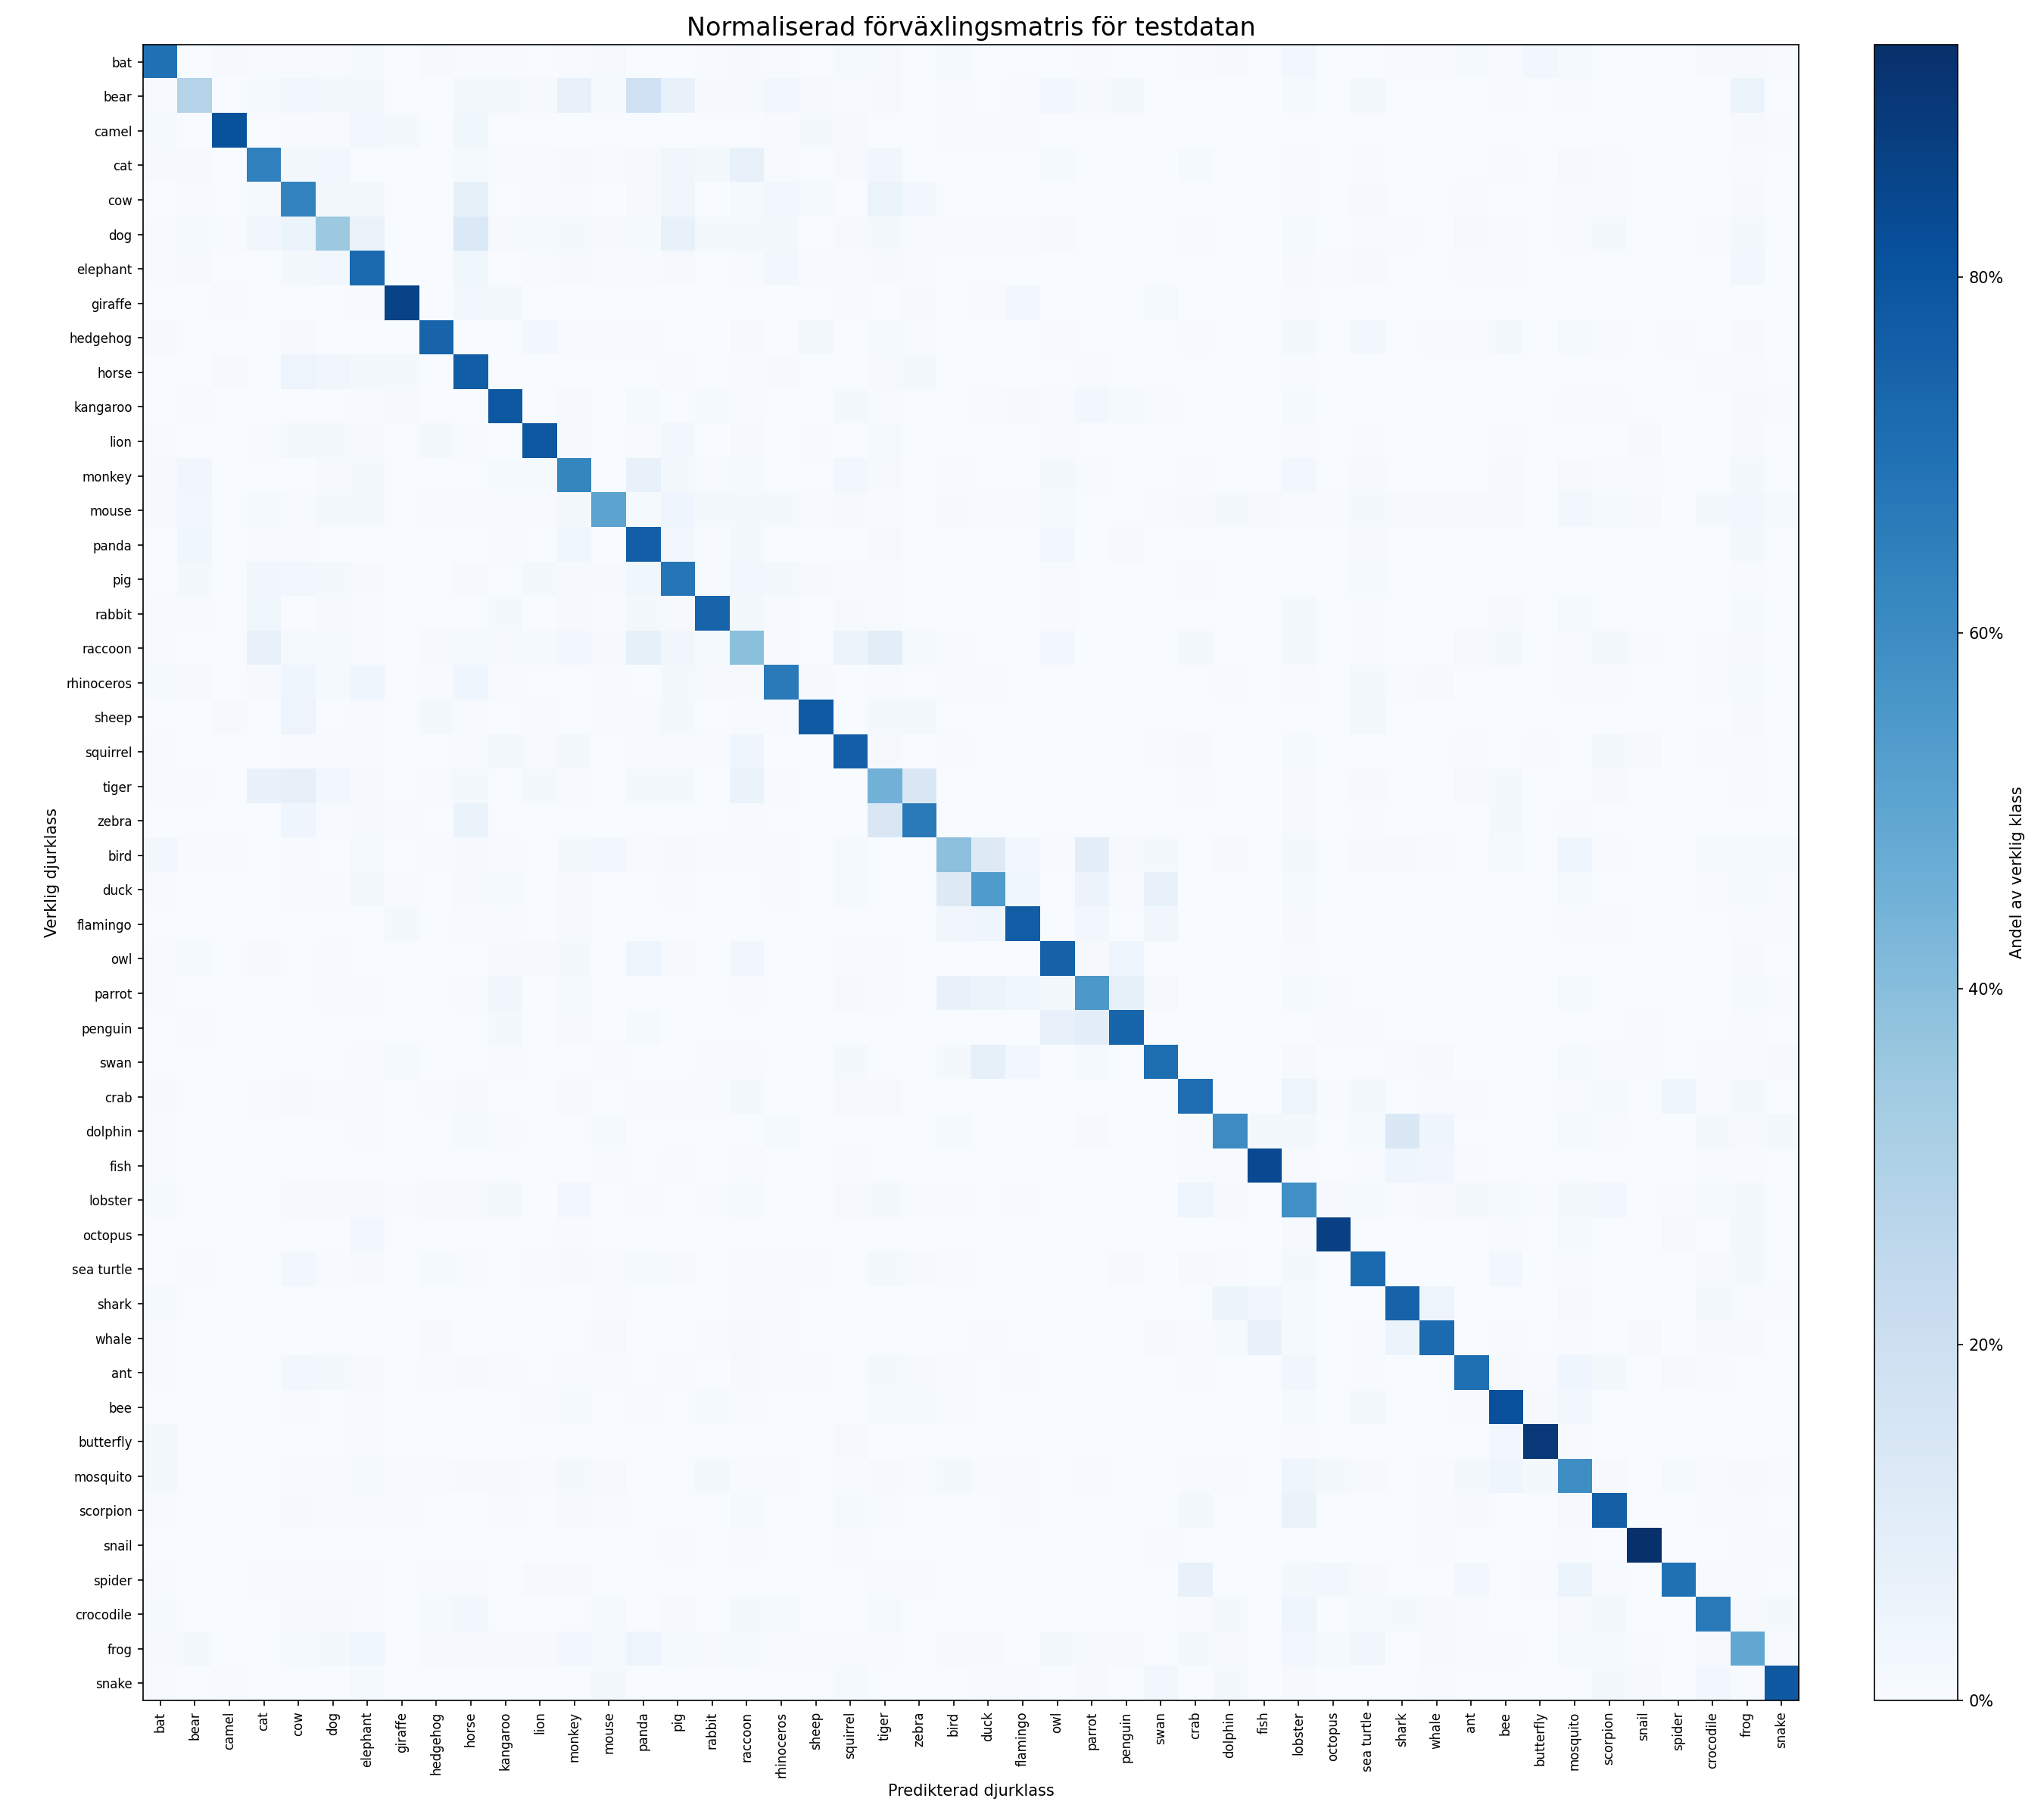

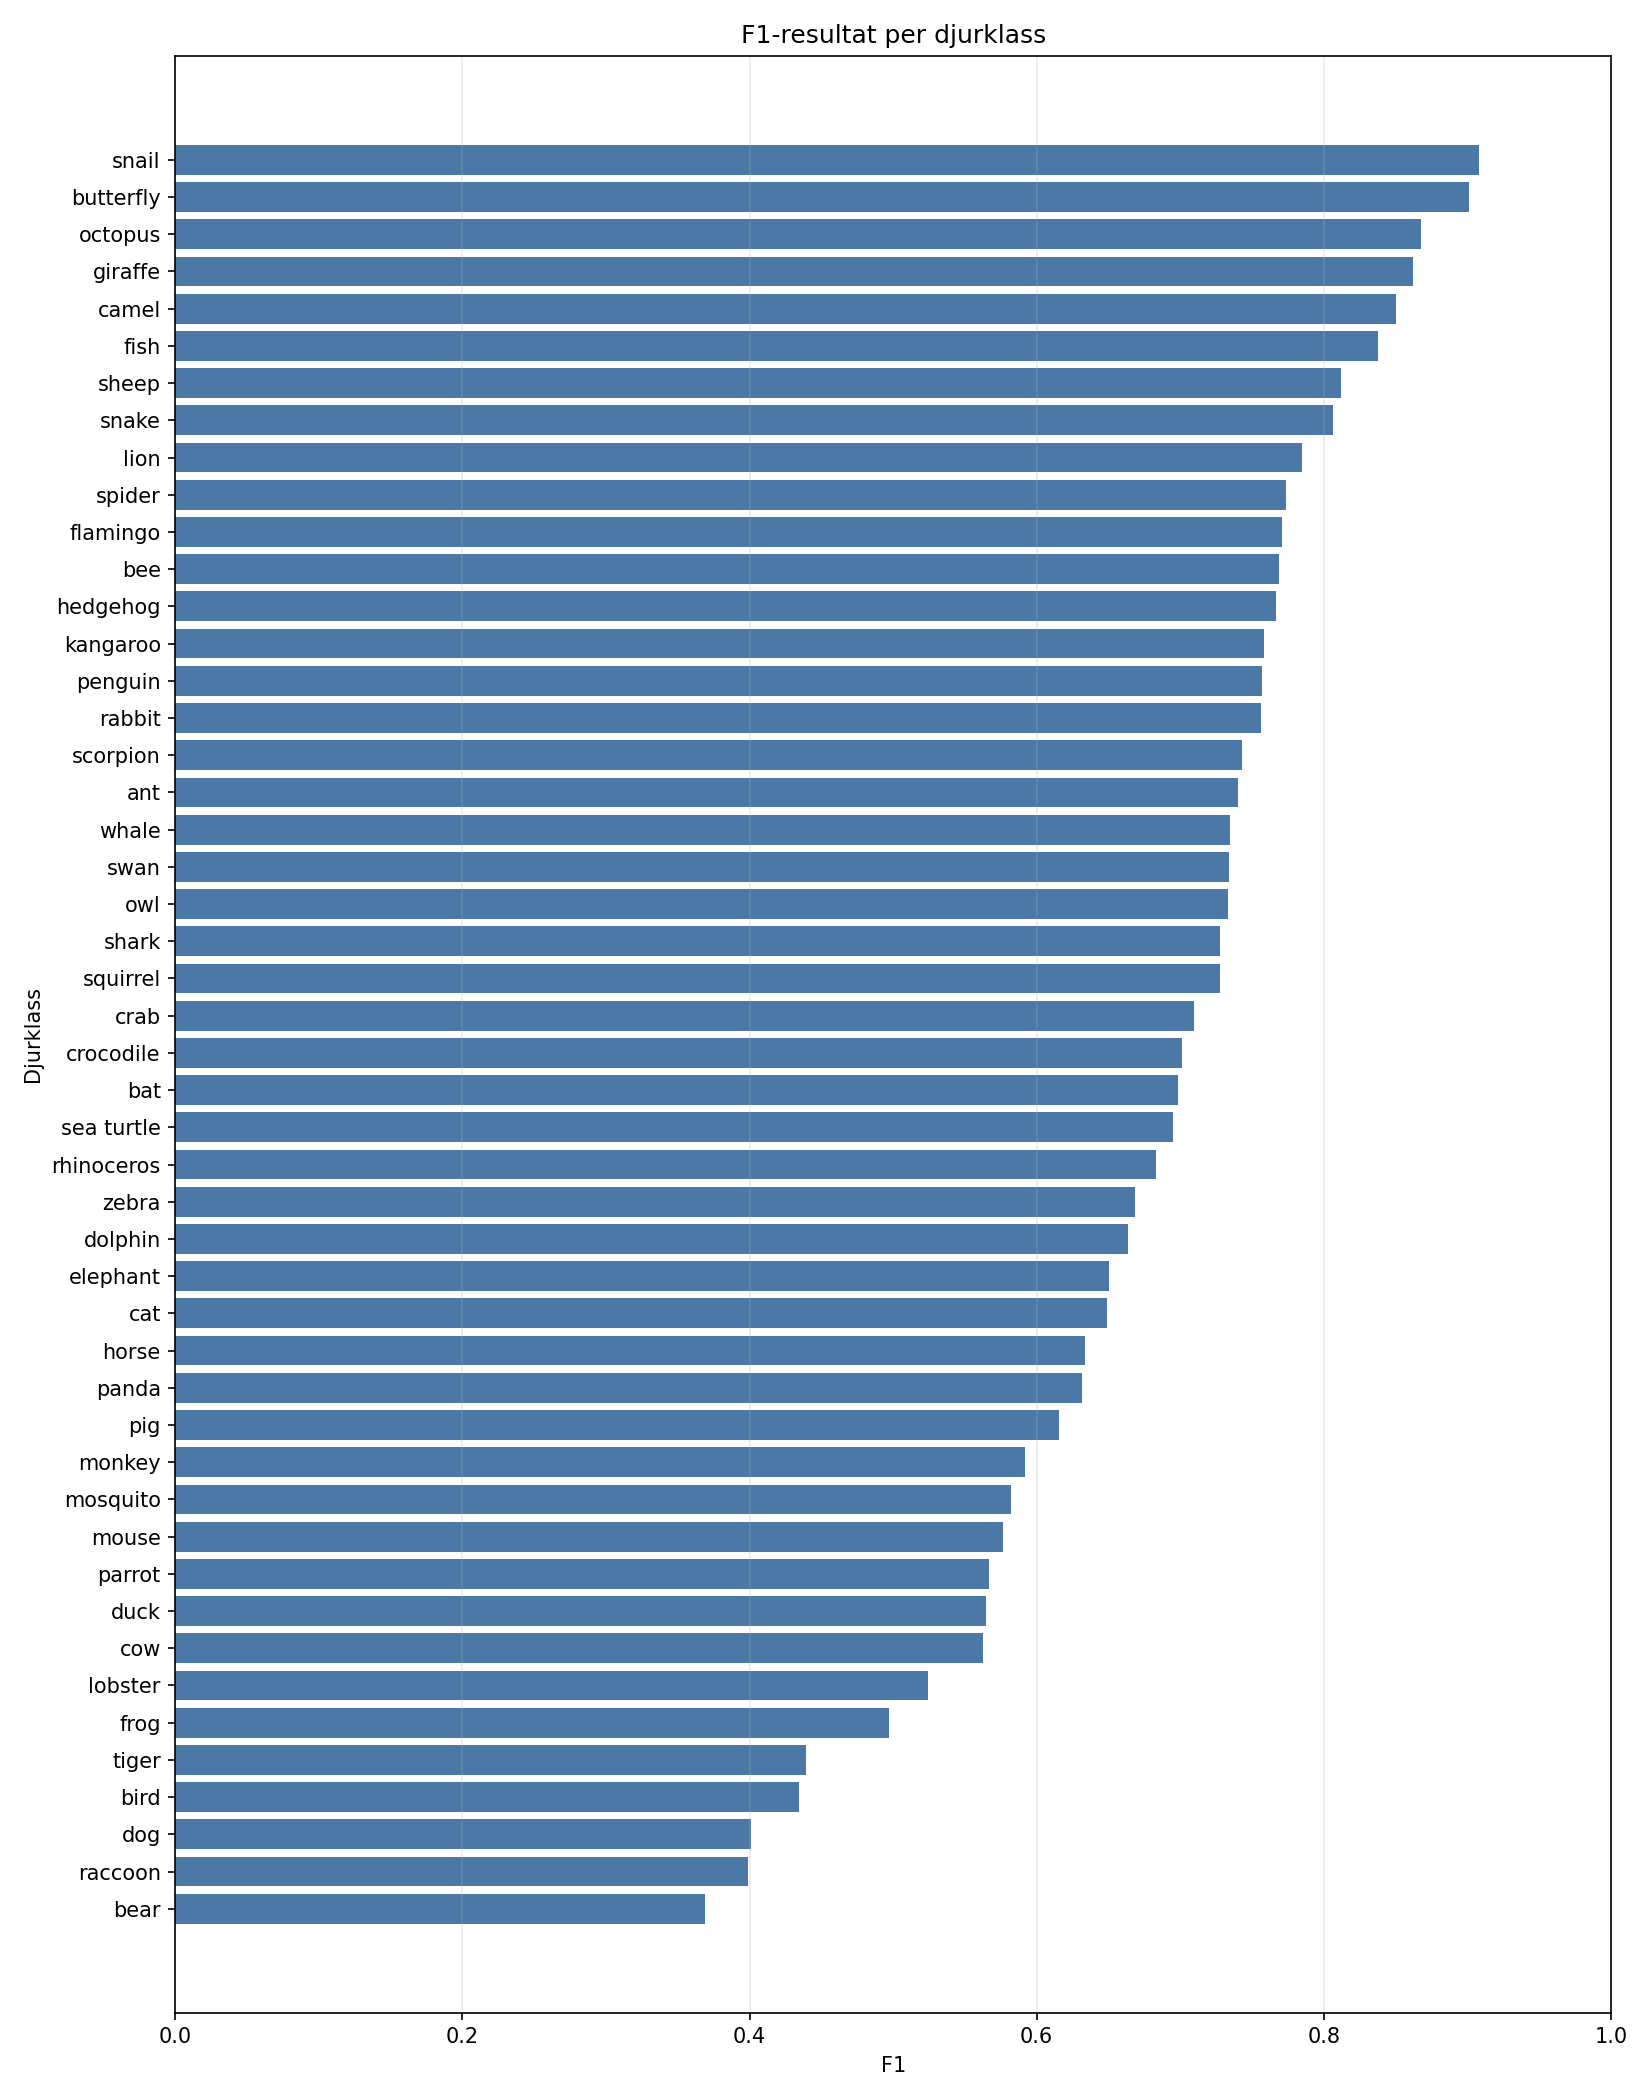

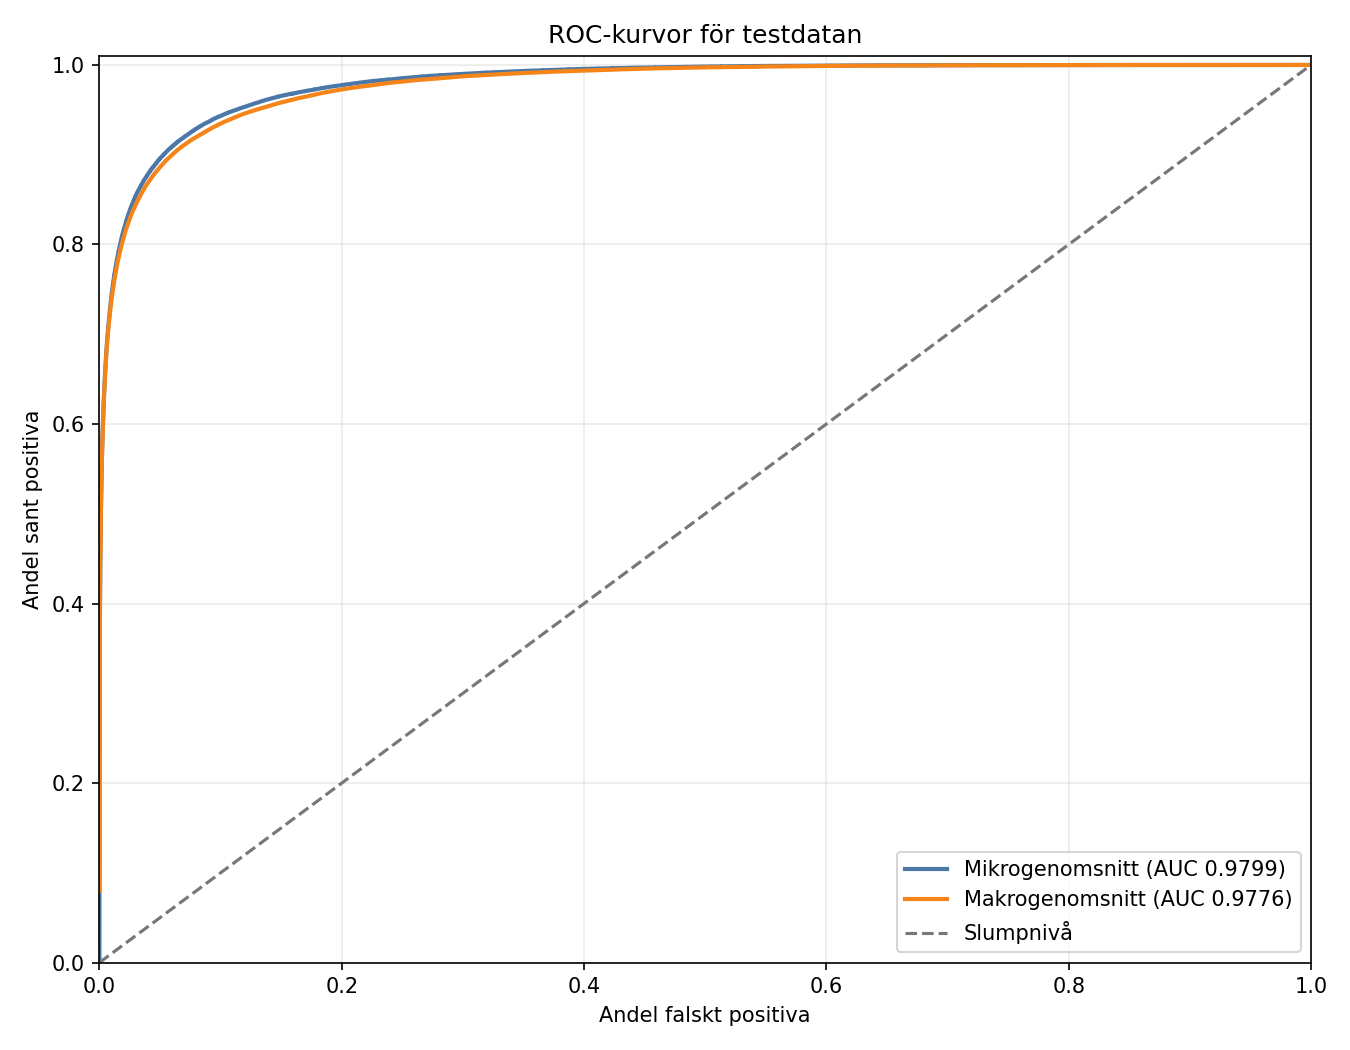

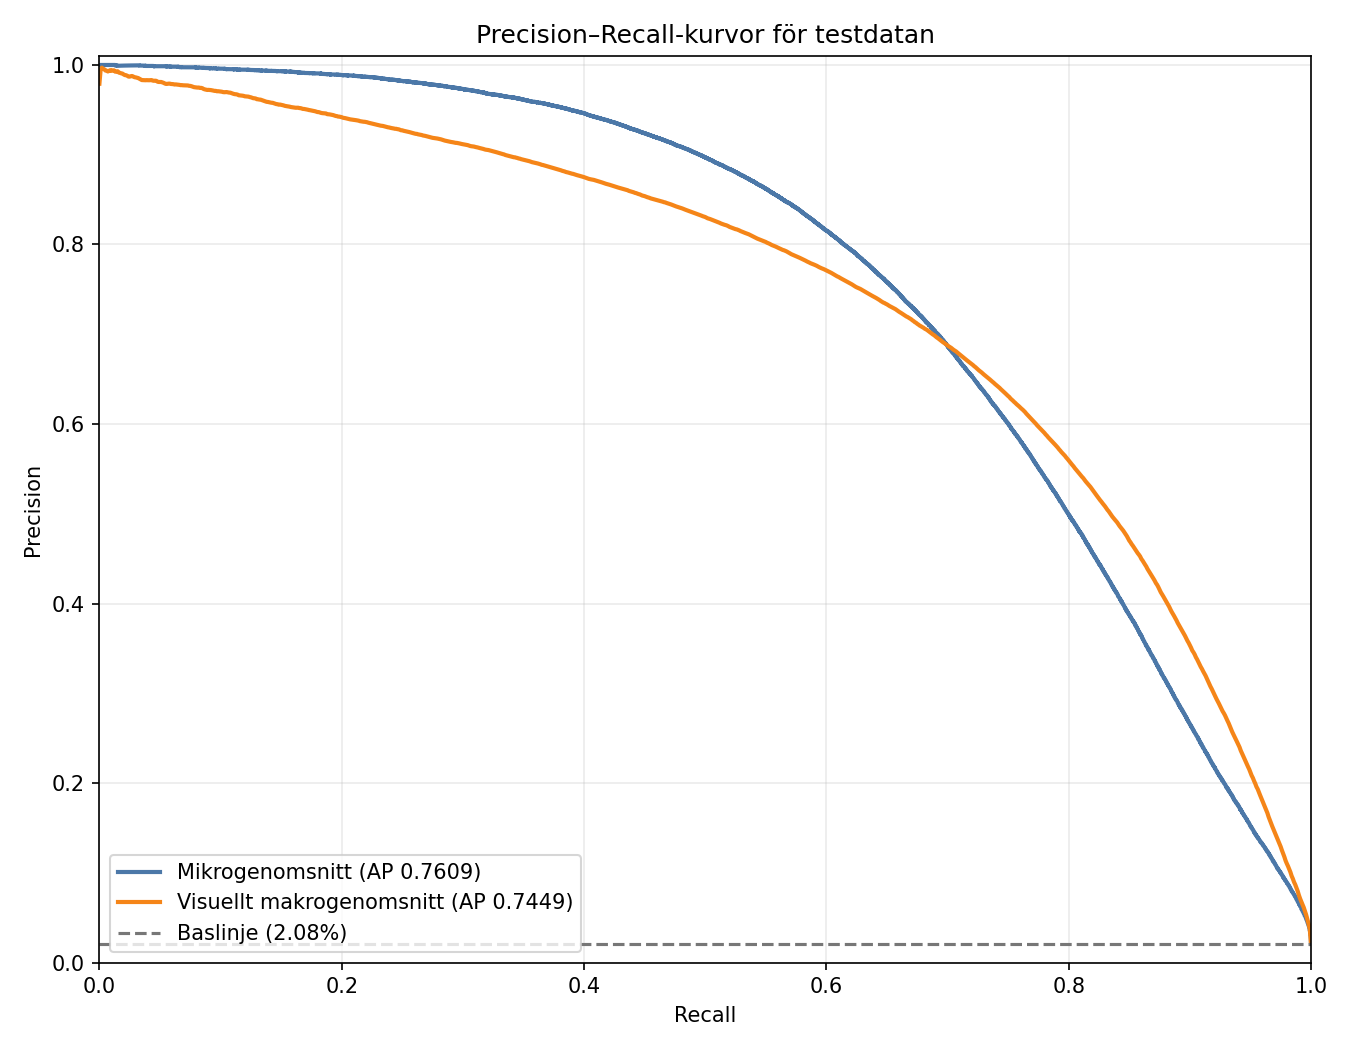

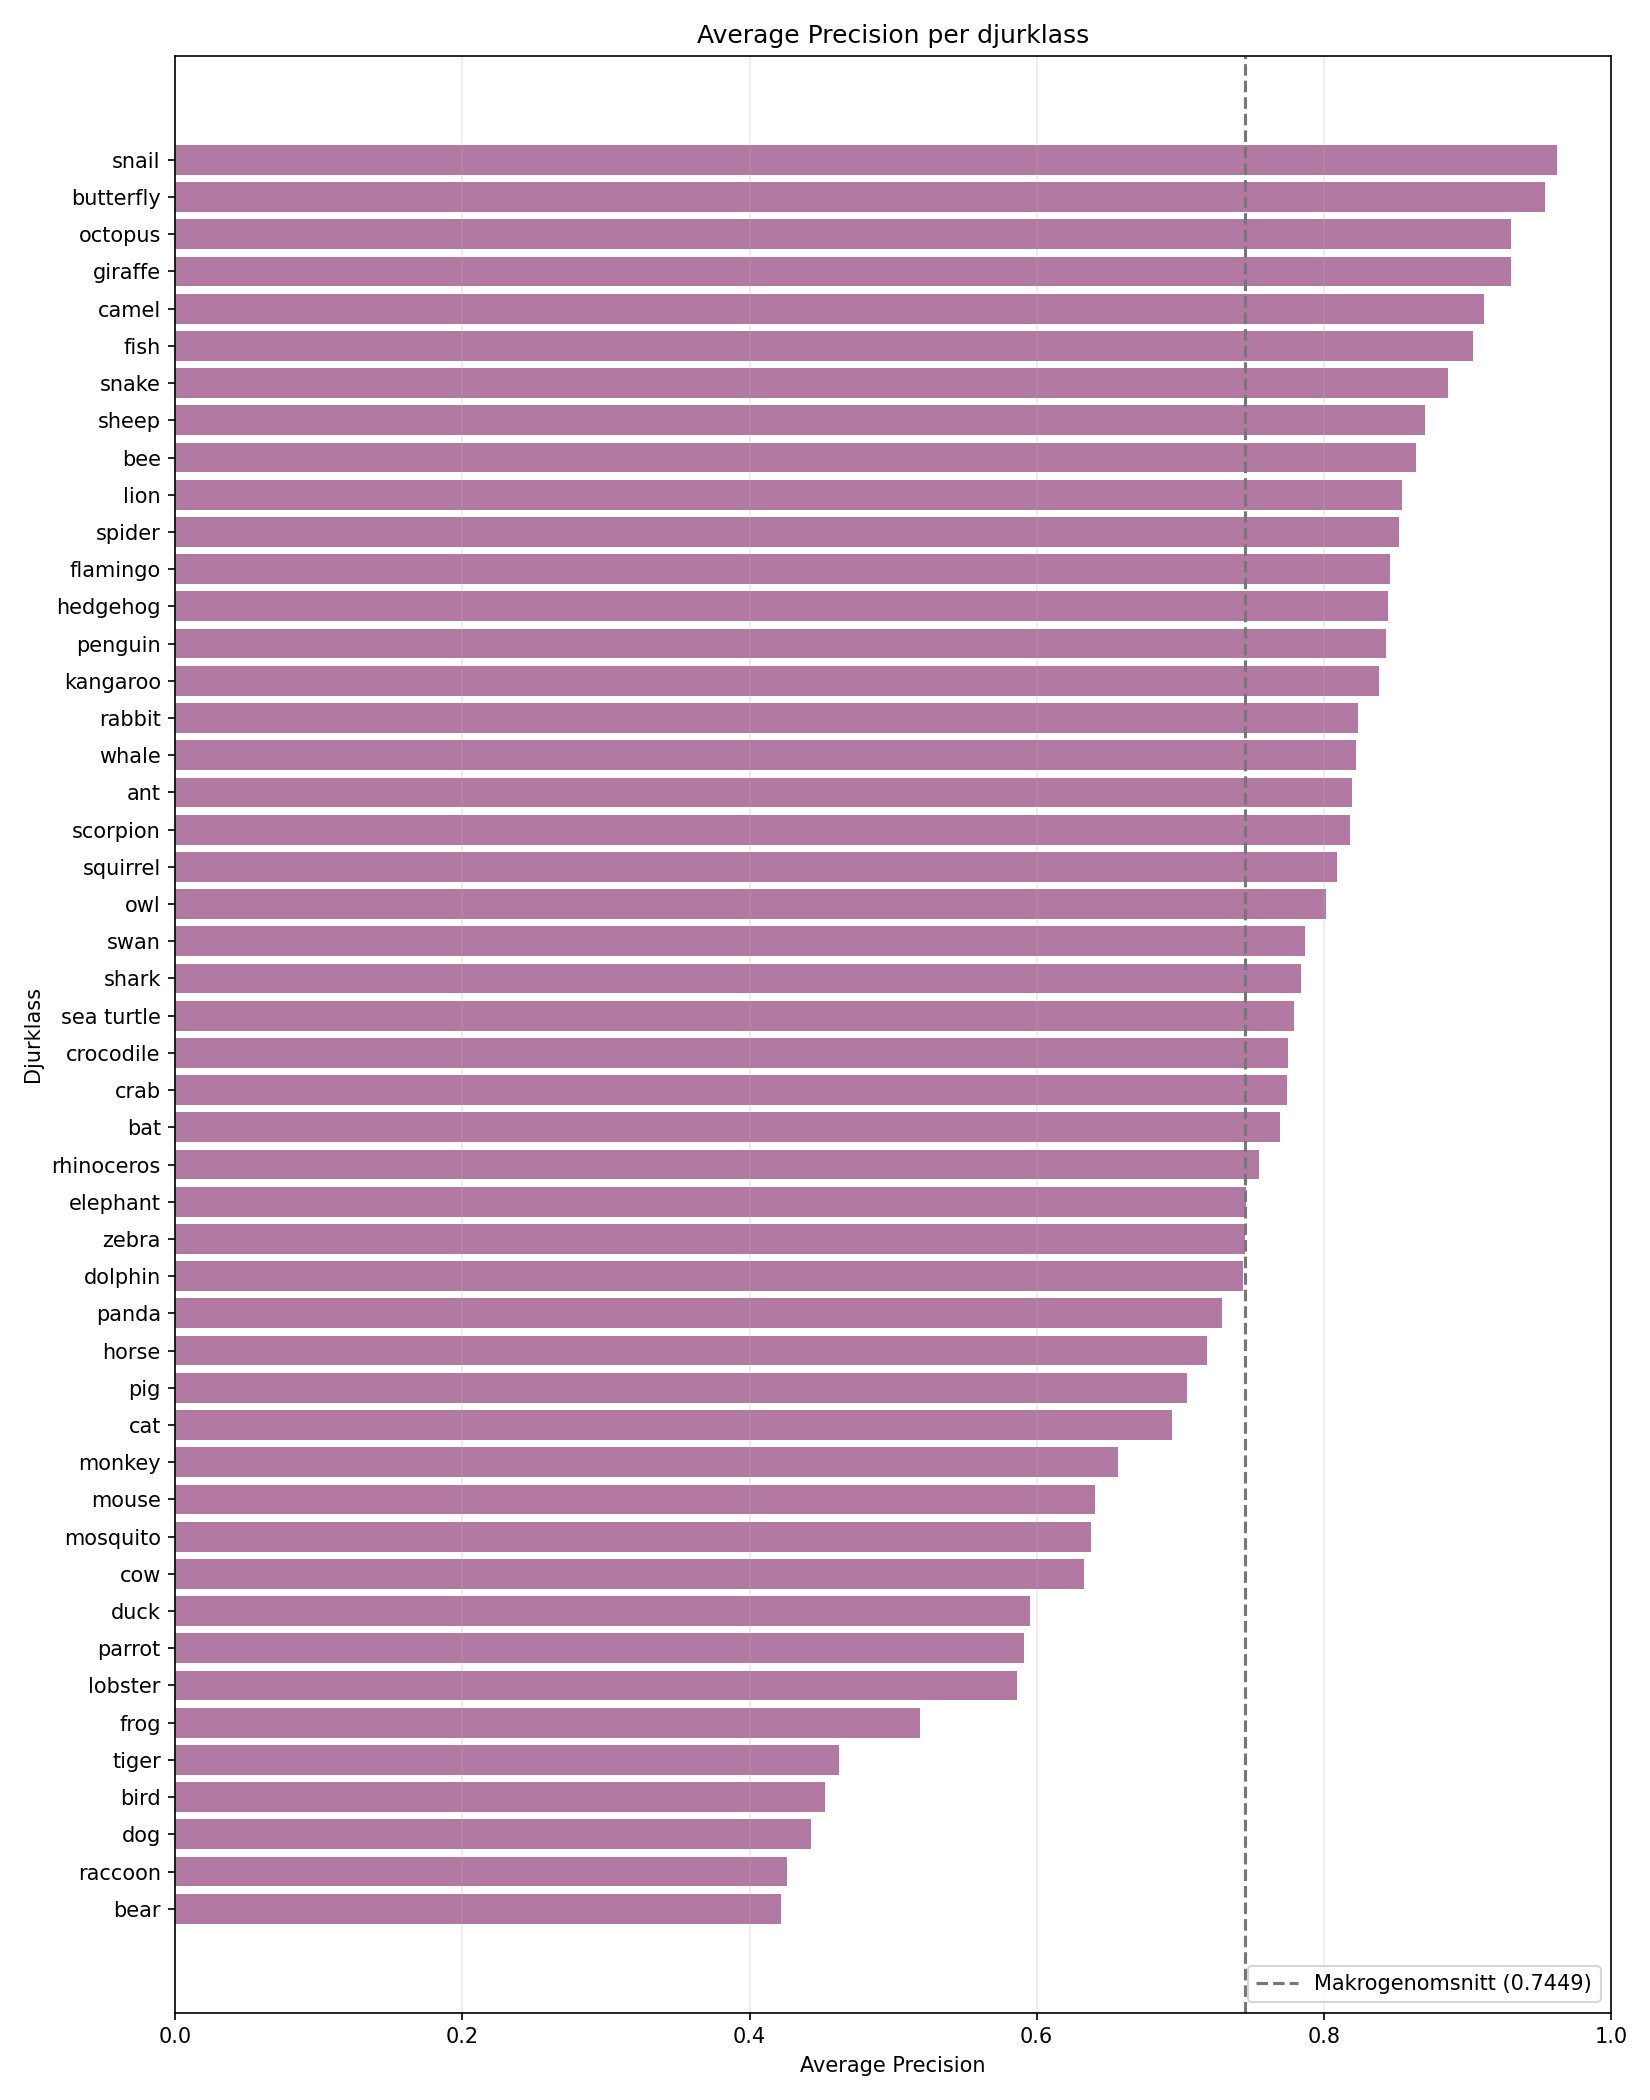

Modell,Test accuracy,Macro precision,Macro recall,Macro F1,Macro ROC-AUC,Macro Average Precision
PCA + KNN,"48,93%","48,76%","48,93%","47,88%","83,21%","46,75%"
CNN,"68,12%","68,53%","68,12%","67,98%","97,76%","74,49%"


In [8]:
evaluation_paths = [
    evaluation_dir / "summary.txt",
    evaluation_dir / "confusion_matrix.png",
    evaluation_dir / "class_performance.png",
    evaluation_dir / "roc_curve.png",
    evaluation_dir / "precision_recall_curve.png",
    evaluation_dir / "average_precision_per_class.png",
]
require_files(
    evaluation_paths,
    "Kör pipeline-steg 7 för att skapa utvärderingsresultaten.",
)

evaluation_summary = (evaluation_dir / "summary.txt").read_text(encoding="utf-8")
print(evaluation_summary)

display(Image(filename=str(evaluation_dir / "confusion_matrix.png"), width=1100))
display(Image(filename=str(evaluation_dir / "class_performance.png"), width=900))
display(Image(filename=str(evaluation_dir / "roc_curve.png"), width=900))
display(Image(filename=str(evaluation_dir / "precision_recall_curve.png"), width=900))
display(Image(filename=str(evaluation_dir / "average_precision_per_class.png"), width=900))

knn_summary_path = knn_evaluation_dir / "summary.txt"
require_files(
    [knn_summary_path],
    "Kör pipeline-steg 7 och utvärdera den aktuella KNN-körningen.",
)
knn_evaluation_summary = knn_summary_path.read_text(encoding="utf-8")

model_comparison = pd.DataFrame(
    [
        {
            "model": "PCA + KNN",
            "test_accuracy": read_summary_metric(
                knn_evaluation_summary, "Testträffsäkerhet"
            ),
            "macro_precision": read_summary_metric(
                knn_evaluation_summary, "Makroprecision"
            ),
            "macro_recall": read_summary_metric(
                knn_evaluation_summary, "Makro-recall"
            ),
            "macro_f1": read_summary_metric(
                knn_evaluation_summary, "Makro-F1"
            ),
            "macro_roc_auc": read_summary_metric(
                knn_evaluation_summary, "Makro ROC-AUC"
            ),
            "macro_average_precision": read_summary_metric(
                knn_evaluation_summary, "Makro Average Precision"
            ),
        },
        {
            "model": "CNN",
            "test_accuracy": read_summary_metric(
                evaluation_summary, "Testträffsäkerhet"
            ),
            "macro_precision": read_summary_metric(
                evaluation_summary, "Makroprecision"
            ),
            "macro_recall": read_summary_metric(
                evaluation_summary, "Makro-recall"
            ),
            "macro_f1": read_summary_metric(
                evaluation_summary, "Makro-F1"
            ),
            "macro_roc_auc": read_summary_metric(
                evaluation_summary, "Makro ROC-AUC"
            ),
            "macro_average_precision": read_summary_metric(
                evaluation_summary, "Makro Average Precision"
            ),
        },
    ]
)

display(
    model_comparison.rename(
        columns={
            "model": "Modell",
            "test_accuracy": "Test accuracy",
            "macro_precision": "Macro precision",
            "macro_recall": "Macro recall",
            "macro_f1": "Macro F1",
            "macro_roc_auc": "Macro ROC-AUC",
            "macro_average_precision": "Macro Average Precision",
        }
    ).style.format(
        {
            "Test accuracy": lambda value: f"{value:.2%}".replace(".", ","),
            "Macro precision": lambda value: f"{value:.2%}".replace(".", ","),
            "Macro recall": lambda value: f"{value:.2%}".replace(".", ","),
            "Macro F1": lambda value: f"{value:.2%}".replace(".", ","),
            "Macro ROC-AUC": lambda value: f"{value:.2%}".replace(".", ","),
            "Macro Average Precision": lambda value: f"{value:.2%}".replace(".", ","),
        }
    ).hide(axis="index")
)

### Tolkning av testresultatet

Den valda CNN-modellens accuracy på testdata är 68,12 procent. Macro precision är 68,53 procent, macro recall 68,12 procent och macro F1 67,98 procent. Eftersom varje klass har lika många testbilder ligger macro- och weighted-måtten mycket nära varandra.

Macro ROC-AUC är 97,76 procent och micro ROC-AUC är 97,99 procent. ROC beräknas med `one-vs-rest`, vilket innebär att varje djurklass jämförs med alla övriga klasser. En hög AUC tillsammans med lägre top-1 accuracy betyder att rätt klass ofta rankas högre än de flesta övriga klasser, men inte alltid högst av samtliga 48 alternativ.

Precision anger hur stor andel av en klass prediktioner som är korrekta, medan recall anger hur stor andel av klassens verkliga bilder som hittas. Precision–Recall-kurvan visar avvägningen mellan måtten vid olika tröskelvärden och Average Precision sammanfattar kurvan i ett värde. I varje `one-vs-rest`-problem är en djurklass positiv och de övriga 47 klasserna negativa. Baslinjen blir därför ungefär 2,08 procent, och precision påverkas tydligt när falskt positiva prediktioner tillkommer.

CNN-modellens macro Average Precision är 74,49 procent och micro Average Precision är 76,09 procent. Macro Average Precision är sklearn-måttet och beräknas som ett oviktat genomsnitt av klassernas AP. Den orange makrokurvan är däremot en visuell sammanvägning där klasskurvorna har interpolerats mot en gemensam recall-skala. Precision–Recall kompletterar ROC-AUC, accuracy och F1 men ersätter inte något av dessa mått.

Den klassiska PCA + KNN-modellen använder samma fullständiga testmängd och når 48,93 procent accuracy, 47,88 procent macro F1, 83,21 procent macro ROC-AUC och 46,75 procent macro Average Precision. På denna testmängd förbättrar CNN-modellen accuracy med 19,19 procentenheter, macro F1 med 20,10 procentenheter, macro ROC-AUC med 14,55 procentenheter och macro Average Precision med 27,74 procentenheter. CNN ger 27 638 fler korrekta klassificeringar, vilket motsvarar 37,6 procent färre fel än KNN.

Resultatet stödjer valet av CNN som huvudmodell i det här projektet: `Conv2D`-lagren kan lära sig lokala och rumsliga bildmönster, medan KNN jämför avstånd i en PCA-komprimerad pixelrepresentation. Jämförelsen gäller den aktuella datasplitten och visar inte att CNN alltid är bättre än KNN i andra problem.

## Analys av konkreta felklassificeringar

Verklig klass,Predikterad klass,Antal,Andel av verklig klass
tiger,zebra,405,"13,50%"
bird,duck,353,"11,77%"
dog,horse,389,"12,97%"
dolphin,shark,402,"13,40%"


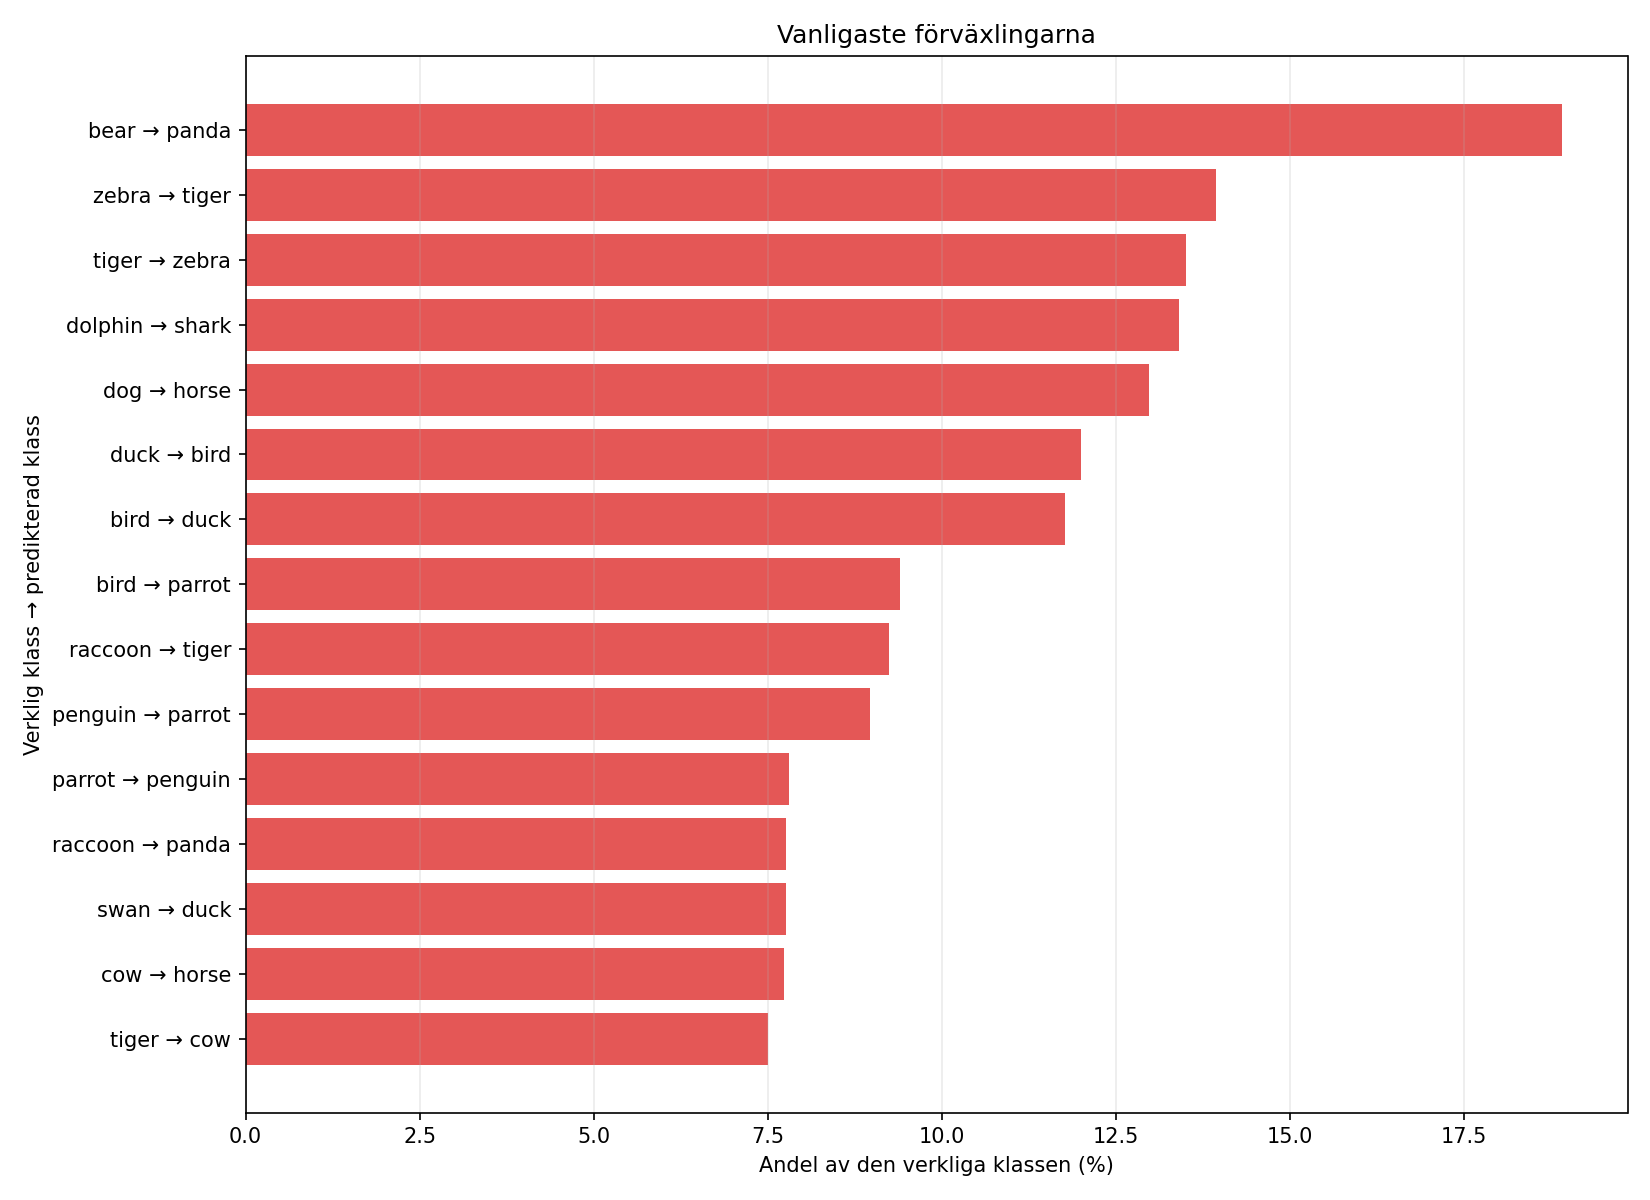

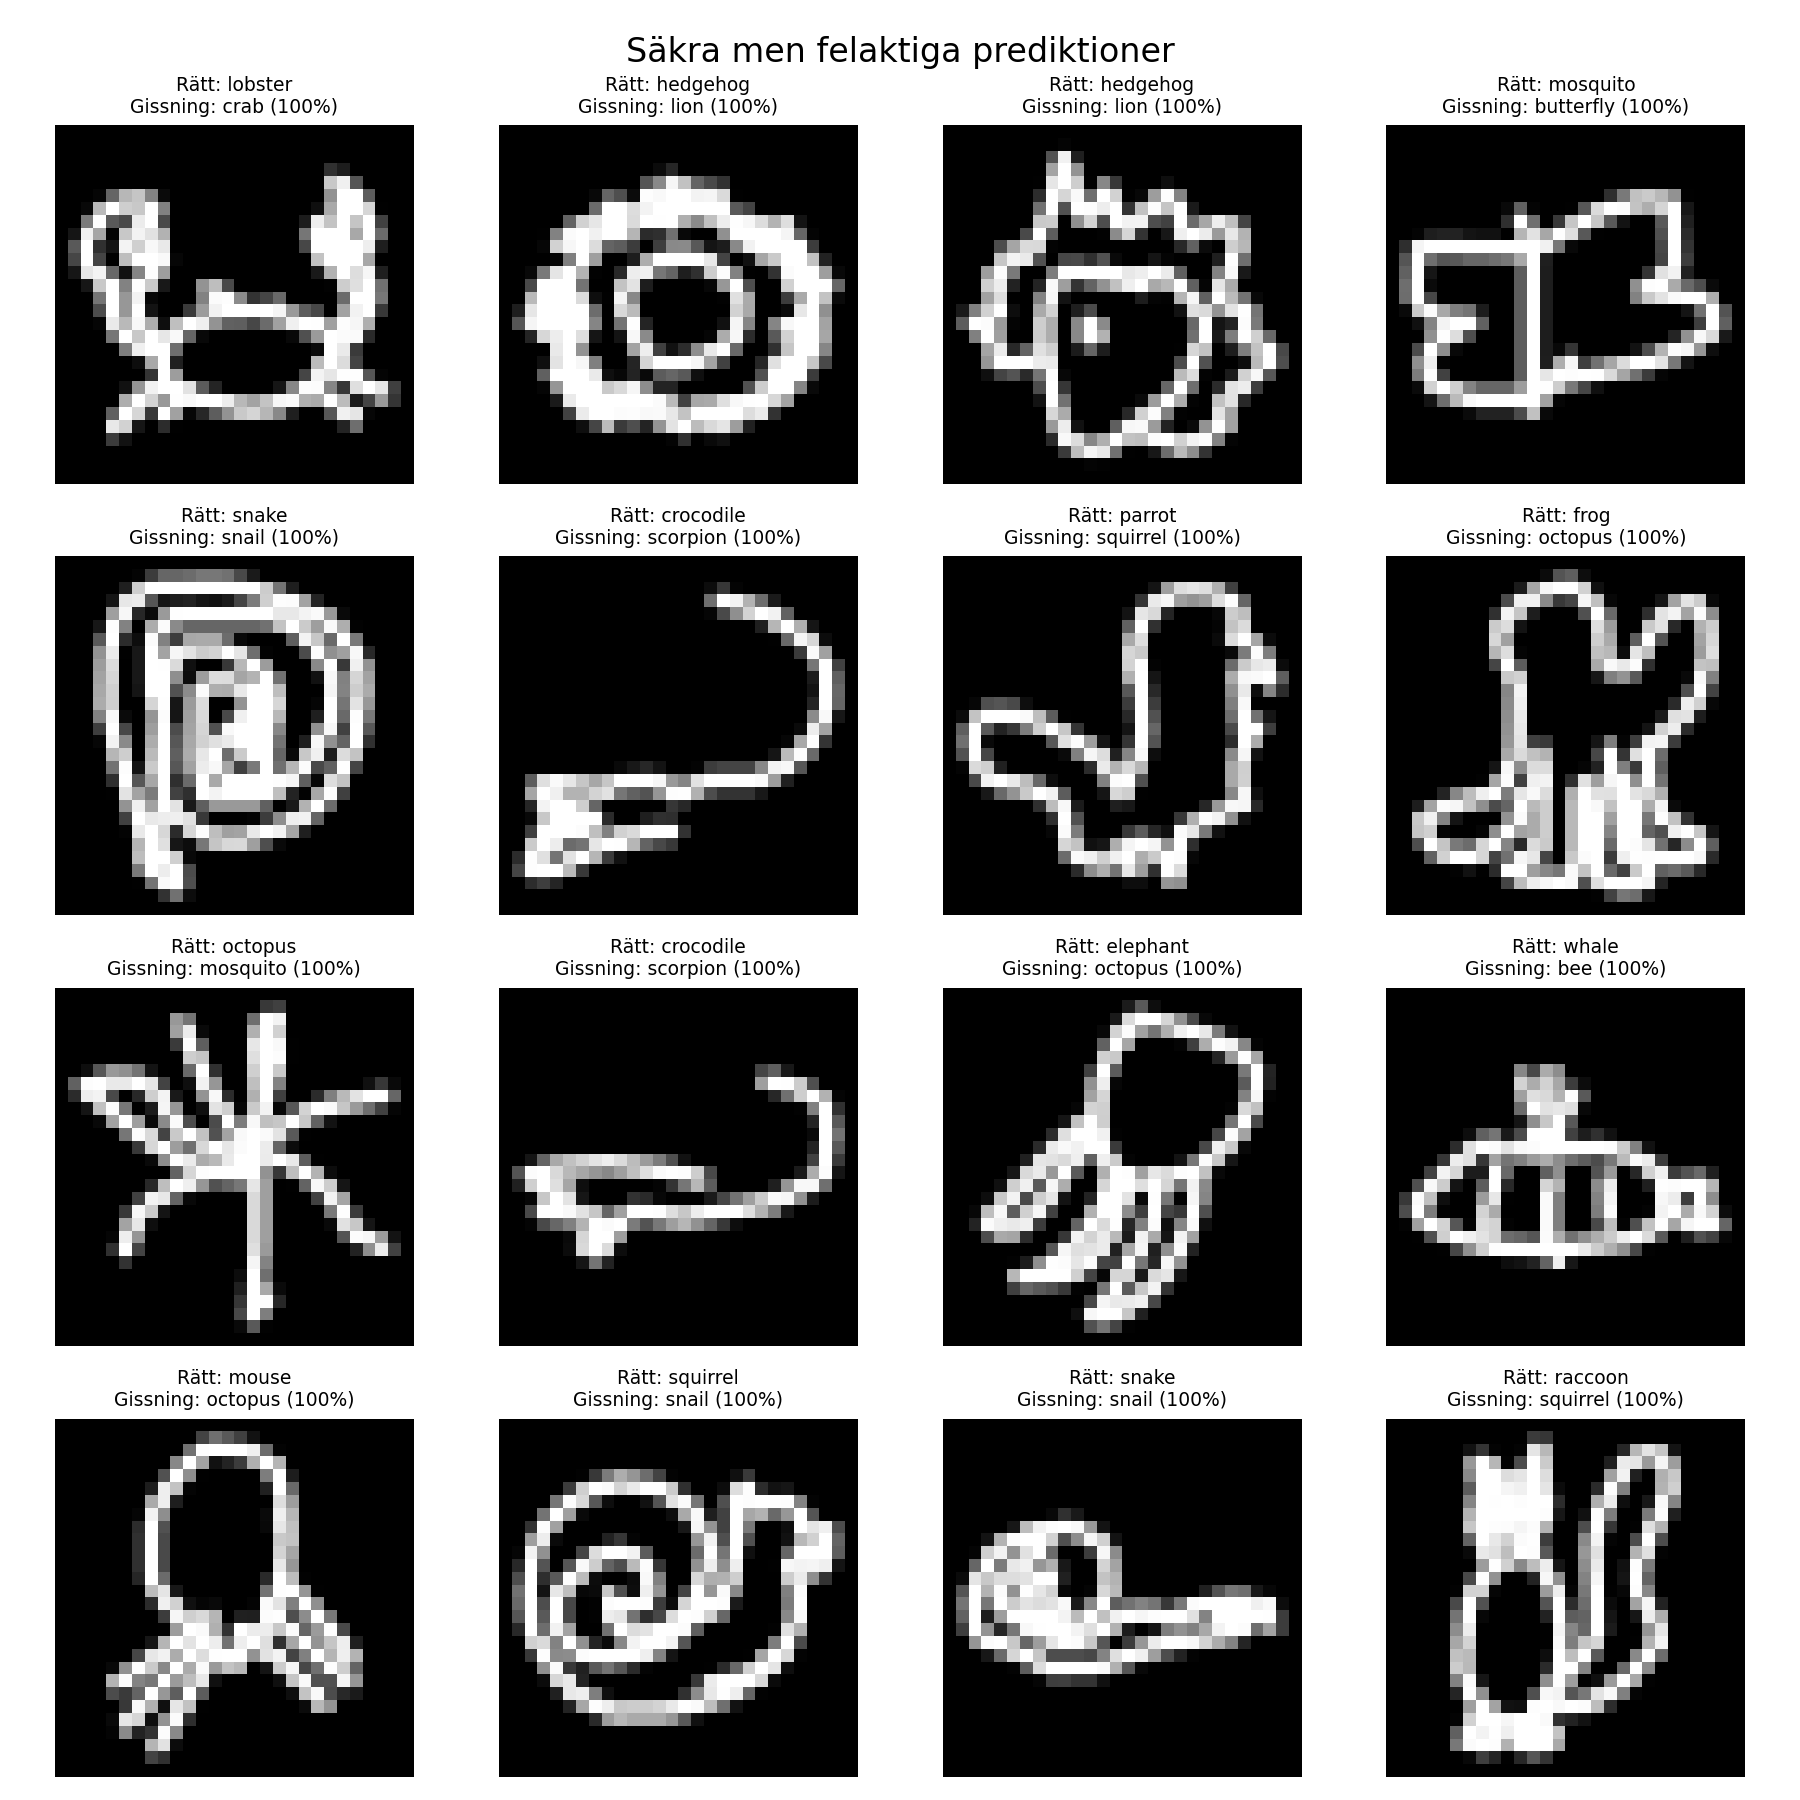

In [9]:
selected_pairs = [
    ("tiger", "zebra"),
    ("bird", "duck"),
    ("dog", "horse"),
    ("dolphin", "shark"),
]
expected_counts = {
    ("tiger", "zebra"): 405,
    ("bird", "duck"): 353,
    ("dog", "horse"): 389,
    ("dolphin", "shark"): 402,
}

confusion_rows = []
for true_animal, predicted_animal in selected_pairs:
    true_mask = predictions["true_animal"] == true_animal
    confusion_mask = true_mask & (
        predictions["predicted_animal"] == predicted_animal
    )
    count = int(confusion_mask.sum())
    true_count = int(true_mask.sum())

    if count != expected_counts[(true_animal, predicted_animal)]:
        raise ValueError(
            f"Oväntat antal för {true_animal} -> {predicted_animal}: {count}"
        )

    confusion_rows.append(
        {
            "true_animal": true_animal,
            "predicted_animal": predicted_animal,
            "count": count,
            "percentage_of_true_class": count / true_count,
        }
    )

selected_confusions = pd.DataFrame(confusion_rows)
display(
    selected_confusions.rename(
        columns={
            "true_animal": "Verklig klass",
            "predicted_animal": "Predikterad klass",
            "count": "Antal",
            "percentage_of_true_class": "Andel av verklig klass",
        }
    )
    .style.format(
        {"Andel av verklig klass": lambda value: f"{value:.2%}".replace(".", ",")}
    )
    .hide(axis="index")
)

for filename, width in [
    ("top_confusions.png", 1000),
    ("misclassified_examples.png", 1000),
]:
    image_path = evaluation_dir / filename
    require_files([image_path], "Kör pipeline-steg 7 för att skapa figuren.")
    display(Image(filename=str(image_path), width=width))

### Tolkning av felen

- **tiger → zebra:** 405 av 3 000 tigrar klassificeras som `zebra`, vilket motsvarar 13,50 procent. Båda ritas ofta som fyrbenta djur i sidoprofil och ränder kan förekomma i båda klasserna.
- **bird → duck:** 353 av 3 000 bilder i den breda klassen `bird` klassificeras som `duck`, vilket motsvarar 11,77 procent. `bird` är en bred klass medan `duck` är en specifik typ av fågel, vilket skapar både visuell och semantisk överlappning.
- **dog → horse:** 389 av 3 000 hundar klassificeras som `horse`, vilket motsvarar 12,97 procent. Förenklade fyrbenta silhuetter kan bli mycket lika, och hundklassen har stor variation i hur kroppen, benen och huvudet ritas.
- **dolphin → shark:** 402 av 3 000 delfiner klassificeras som `shark`, vilket motsvarar 13,40 procent. Båda ritas ofta som horisontella, strömlinjeformade kroppar med fenor.

Alla fyra felen sker mellan djur inom samma breda grupp. Mönstret är förenligt med hypotesen från PCA och UMAP om att form, orientering och streckmönster har stor betydelse för både representationerna och modellens beslut, men felparen bevisar inte hypotesen på egen hand.

## Begränsningar

- Bildernas låga upplösning gör att små särskiljande detaljer ofta försvinner.
- Fria teckningar ger stor variation inom klasserna, och vissa etiketter är mer generella än andra.
- Resultatet har mätts på data från Quick, Draw! och visar inte automatiskt hur modellen fungerar på teckningar från en annan källa.
- PCA och UMAP analyserar råa bildpixlar. En senare analys av CNN-modellens inlärda features skulle kunna visa tydligare semantisk struktur.
- Projektet jämför CNN med en PCA + KNN-baseline, men någon systematisk hyperparameteroptimering eller jämförelse med fler modellfamiljer har inte genomförts.
- Den slutliga CNN-modellen har tränats en gång i `eager mode` med seed 42. Upprepade körningar eller osäkerhetsintervall behövs för att mäta resultatets variation.
- De äldre CNN-körningarna gjordes i `graph mode` med TensorFlow Metal och används därför endast som utvecklingshistorik, inte som direkt jämförbara slutresultat.
- Dataförberedelsen kontrollerar inte exakta dubbletter, vilket innebär att mycket lika teckningar kan finnas i flera delar av datasetet.

## Slutsats

Zoodle visar att en relativt kompakt CNN kan lära sig användbara mönster i handritade djurbilder. Den slutliga CNN-modellen, som tränades och verifierades i `eager mode`, når 68,12 procent accuracy och 67,98 procent macro F1 på testdata. Den överträffar tydligt PCA + KNN-baselinen, som når 48,93 procent accuracy och 47,88 procent macro F1, och ligger även klart över slumpnivån på ungefär 2,08 procent för 48 balanserade klasser. Att CNN-modellens validerings- och testresultat ligger nära varandra tyder på att modellen generaliserar väl inom den aktuella datasplitten. Upprepade körningar och data från en annan källa skulle behövas för en bredare slutsats.

Modellen fungerar bäst för djur med tydliga och särpräglade silhuetter, medan visuellt eller semantiskt överlappande klasser är den största utmaningen. PCA, UMAP och felanalysen pekar mot samma slutsats: streck, form och orientering är centrala för hur bilderna organiseras och hur modellen fattar sina beslut.